# Models evaluator notebook  

## Load and prepare data

### Load data

In [144]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
from rich.pretty import pprint
import matplotlib.pyplot as plt
from collections import defaultdict
from more_itertools import unique_justseen
from aymurai.database.utils import text_to_uuid
from aymurai.api.endpoints.routers.misc.document_extract import extraction

IS_OPENAI_FILE = True # or False
IS_MAIN_DF = 'documents-02-08-sin05-conOpenAI.csv' # or False
OPENAI_PREDICTION_FILE = "predictions_openai-alldocsv1.pkl"
AYMURAI_JSONS_PATH = '/Users/sofi/Desktop/collectiveAI/projects/AymurAI' # '/Users/sofi/Desktop/collectiveai/projects/AymurAI/'
DOCS_PATH = '/Users/sofi/Desktop/CollectiveAI/projects/data-genero/backend/resources/data/sample/' # '/Users/sofi/Desktop/collectiveai/projects/AymurAI/backend/resources/data/sample/'

In [3]:
if IS_OPENAI_FILE:
    try:
        with open(OPENAI_PREDICTION_FILE, "rb") as file:
            predictions = pickle.load(file)
    except Exception as e:
        print(f'There is no file named {OPENAI_PREDICTION_FILE}, please redefine OPENAI_PREDICTION_FILE variable')
else:
    print('There is no file of predictions')

if IS_MAIN_DF:
    df = pd.read_csv(IS_MAIN_DF)
else:
    print('Calculating main df from jsons from AimurAI outputs')
    json_files = [f for f in os.listdir(AYMURAI_JSONS_PATH) if f.endswith('.json')]
    para_files = [f for f in json_files if f.startswith('anonymization_paragraph')]
    para_df = pd.concat([pd.read_json(AYMURAI_JSONS_PATH + fname) for fname in para_files], ignore_index=True)

    doc_files = [f for f in json_files if f.startswith('anonymization_document') and not 'paragraph' in f]
    doc_df = pd.concat([pd.read_json(AYMURAI_JSONS_PATH + fname) for fname in doc_files], ignore_index=True)

    doc_para_files = [f for f in json_files if f.startswith('anonymization_document_paragraph')]
    doc_para_df = pd.concat([pd.read_json(AYMURAI_JSONS_PATH + fname) for fname in doc_para_files], ignore_index=True)

    doc_df = doc_df.copy()
    doc_para_df = doc_para_df.copy()
    doc_df['id'] = doc_df['id'].astype(str)
    doc_para_df['document_id'] = doc_para_df['document_id'].astype(str)


    merged_df = pd.merge(
        doc_para_df,
        doc_df[['id', 'created_at', 'name']],
        left_on='document_id',
        right_on='id',
        how='left'
    ).rename(columns={'id_x': 'id'}).drop(columns=['id_y'])

    df = pd.merge(
        para_df,
        merged_df,
        left_on='id',
        right_on='paragraph_id',
        how='left'
    )

In [4]:
import numpy as np
np.sum(df['name'] != df['doc'])

142

### Function definitions

In [24]:
def get_paragraph_predictions(row,predictions):
    preds = predictions.get(row['name'], [])
    return [
        p for p in preds
        if p['start_char'] >= (row['start_char']) and (p['end_char'] <= row['end_char'])
    ]

def metrics_per_entity_by_span(df, is_openai = False):
    # acumula TP/FP/FN por entidad (label)
    counts = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

    for i in range(len(df)):
        # cada celda puede ser una lista de dicts; si falla, lista vacía
        try:
            val_list = eval(df.validation.iloc[i])
        except:
            val_list = []
        try:
            pred_list = eval(df.prediction.iloc[i])
        except:
            try:
                pred_list = df.prediction.iloc[i]
            except:
                pred_list = []
            
        # sets de spans por label: {(start, end), ...}
        val_spans = defaultdict(set)
        pred_spans = defaultdict(set)
        start_char = int(df.start_char.iloc[i])

        # VALIDATION (val)
        for v in (val_list or []):
            if not isinstance(v, dict):
                continue
            lab = (v.get('attrs', {}).get('aymurai_label', None)) or v.get('label', None)
            lab = lab.replace('CORREO_ELECTRÓNICO','CORREO_ELECTRONICO')
            s = v.get('attrs', {}).get('aymurai_alt_start_char', None)
            e = v.get('attrs', {}).get('aymurai_alt_end_char', None)
            if lab is not None and s is not None and e is not None:
                val_spans[lab].add((int(s), int(e)))
                #print('validation:')
                #print(lab, s, e)
        #print('val_spans: ', val_spans)

        # PREDICTIONS
        for p in (pred_list or []):
            if not isinstance(p, dict):
                continue
            lab = p.get('attrs', {}).get('aymurai_label', None) or p.get('label', None)
            lab = lab.replace('CORREO_ELECTRÓNICO','CORREO_ELECTRONICO')
            s = p.get('attrs', {}).get('aymurai_alt_start_char', None) or p.get('start_char', None)
            e = p.get('attrs', {}).get('aymurai_alt_end_char', None) or p.get('end_char', None)
            if lab is not None and s is not None and e is not None:
                if is_openai:
                    pred_spans[lab].add((int(s)-start_char, int(e)- start_char))
                else:
                    pred_spans[lab].add((int(s), int(e)))

                #print('prediction:')
                #print(lab, s, e)
        #print('pred_spans: ', pred_spans)
        # actualizar TP/FP/FN por label en esta fila
        for lab in set(list(val_spans.keys()) + list(pred_spans.keys())):
            vs = val_spans.get(lab, set())
            ps = pred_spans.get(lab, set())
            tp = len(ps & vs)
            fp = len(ps - vs)
            fn = len(vs - ps)
            counts[lab]['tp'] += tp
            counts[lab]['fp'] += fp
            counts[lab]['fn'] += fn

    # calcular métricas por label + micro/macro
    out = {'per_label': {}, 'micro': {}, 'macro': {}}
    micro_tp = micro_fp = micro_fn = 0

    for lab, c in counts.items():
        tp, fp, fn = c['tp'], c['fp'], c['fn']
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support   = tp + fn  # cantidad de entidades de referencia (validation) para ese label
        out['per_label'][lab] = {'precision': precision, 'recall': recall, 'f1': f1, 'support': support}
        micro_tp += tp; micro_fp += fp; micro_fn += fn

    # micro
    micro_p = micro_tp / (micro_tp + micro_fp) if (micro_tp + micro_fp) > 0 else 0.0
    micro_r = micro_tp / (micro_tp + micro_fn) if (micro_tp + micro_fn) > 0 else 0.0
    micro_f = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) > 0 else 0.0
    out['micro'] = {'precision': micro_p, 'recall': micro_r, 'f1': micro_f, 'support': micro_tp + micro_fn}

    # macro (promedio simple entre labels presentes)
    if out['per_label']:
        L = len(out['per_label'])
        macro_p = sum(m['precision'] for m in out['per_label'].values()) / L
        macro_r = sum(m['recall']    for m in out['per_label'].values()) / L
        macro_f = sum(m['f1']        for m in out['per_label'].values()) / L
    else:
        macro_p = macro_r = macro_f = 0.0
    out['macro'] = {'precision': macro_p, 'recall': macro_r, 'f1': macro_f}

    return out
def metrics_for_label(df, target = 'text'):
    tp, fp, fn = 0, 0, 0
    for i in range(len(df)):
        try:
            val = eval(df.validation.iloc[i])[0]
        except:
            val = []
        try:
            pred = eval(df.prediction.iloc[i])[0]
        except:
            pred = []
        
        if target == 'text':
            text_val = val.get('attrs',None).get('aymurai_alt_text',None) if val else None
            text_pred= pred.get('text',None) if pred else None
            pred_set = set((text_pred,))
            val_set = set((text_val,))

        elif target == 'label':
            label_pred= pred.get('label',None) if pred else None
            label_val= val.get('attrs',None).get('aymurai_label',None) if val else None
            pred_set = set((label_pred,))
            val_set = set((label_val,))

        elif target == 'both':
            text_val = val.get('attrs',None).get('aymurai_alt_text',None) if val else None
            text_pred= pred.get('text',None) if pred else None
            label_pred= pred.get('label',None) if pred else None
            label_val= val.get('attrs',None).get('aymurai_label',None) if val else None
            pred_set = set((text_pred, label_pred))
            val_set = set((text_val, label_val))

        else:
            raise ValueError("Target must be one of 'text', 'label', or 'both'")
        if len(pred_set)>0 or len(val_set)>0: 
            tp += len(pred_set & val_set)
            fp += len(pred_set - val_set)
            fn += len(val_set - pred_set)

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / ( tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (recall + precision) > 0 else 0

    return {'recall': recall, 'precision': precision, 'f1': f1}

def _metrics_to_df(out):
    rows = []
    for lab, m in out.get('per_label', {}).items():
        rows.append({
            'label': str(lab),
            'precision': float(m.get('precision', 0) or 0),
            'recall':    float(m.get('recall', 0) or 0),
            'f1':        float(m.get('f1', 0) or 0),
            'support':   m.get('support', 0)
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        # Evita crash si support viene como NaN/None/str
        df['support'] = pd.to_numeric(df['support'], errors='coerce').fillna(0).astype(int)
        df = df.sort_values('support', ascending=False).reset_index(drop=True)
    return df

def plot_per_label_bars(out, top=None, sort_by='support', aclaration_title='', alphabetical=False):
    df = _metrics_to_df(out)
    if df.empty:
        print("No per-label data to plot."); 
        return
    if alphabetical:
        df = df.sort_values('label', ascending=True)
    elif sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=False)
    if top:
        df = df.head(top)

    labels = df['label'].tolist()
    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, len(labels)*0.9), 5),dpi = 150)
    ax.bar(x - width, df['precision'].values, width, label='Precision')
    ax.bar(x,         df['recall'].values,    width, label='Recall')
    ax.bar(x + width, df['f1'].values,        width, label='F1')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_title('Per-label Precision / Recall / F1 '+ aclaration_title)
    ax.legend(loc = 'best')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.4)

    # Anotar support arriba del rango actual del eje (sin asumir [0,1])
    y_top = ax.get_ylim()[1]
    y_text = y_top * 0.8
    for i, s in enumerate(df['support'].values):
        ax.text(i, y_text, f'n={int(s)}', ha='center', va='top', fontsize=11)

    plt.tight_layout()
    plt.show()

def plot_pr_scatter(out, min_support=1, annotate_top=None):
    df = _metrics_to_df(out)
    if df.empty:
        print("No per-label data to plot."); 
        return
    df = df[df['support'] >= min_support].copy()
    if df.empty:
        print("No points after min_support filter."); 
        return

    # tamaños relativos según support (evita división por cero)
    max_sup = df['support'].max()
    if max_sup <= 0:
        size = np.full(len(df), 100.0)
    else:
        size = 100 * (0.3 + 0.7 * (df['support'] / max_sup))

    fig, ax = plt.subplots(figsize=(6, 6),dpi = 150)
    ax.scatter(df['recall'].values, df['precision'].values, s=size, alpha=0.8)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_title('Precision vs Recall by Label (size ~ support)')
    ax.set_ylim(0, 1.4)

    # Anotar los top por support
    if annotate_top:
        top_df = df.sort_values('support', ascending=False).head(annotate_top)
    else:
        top_df = df.sort_values('support', ascending=False)

    for _, r in top_df.iterrows():
        ax.annotate(r['label'], (r['recall'], r['precision']), textcoords='offset points', xytext=(5, 5))

    plt.tight_layout()
    plt.show()

def plot_micro_macro(out):
    mm = out.get('micro', {}) or {}
    ma = out.get('macro', {}) or {}
    metrics = ['precision', 'recall', 'f1']
    micro_vals = [float(mm.get(m, 0) or 0) for m in metrics]
    macro_vals = [float(ma.get(m, 0) or 0) for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(6, 4),dpi = 150)
    b1 = ax.bar(x - width/2, micro_vals, width, label='Micro')
    b2 = ax.bar(x + width/2, macro_vals, width, label='Macro')

    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in metrics])
    ax.set_title('Micro vs Macro')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, 1.4)

    # Anotar valores respetando límites del eje
    y_top = ax.get_ylim()[1]
    for i, v in enumerate(micro_vals):
        ax.text(i - width/2, min(v + 0.02*y_top, y_top*0.98), f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(macro_vals):
        ax.text(i + width/2, min(v + 0.02*y_top, y_top*0.98), f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()



### Load joined_paragraphs from docs

In [6]:
def take_start_end_paragraphs(paragraphs):
    # Create start and end character positions
    start_end_chars = []
    current_pos = 0

    for i, paragraph in enumerate(paragraphs):
        start_char = current_pos
        end_char = start_char + len(paragraph)
        start_end_chars.append(
            {
                "paragraph_position": i,
                "text": paragraph,
                "paragraph_id": str(text_to_uuid(paragraph)).replace("-", ""),
                "start_char": start_char,
                "end_char": end_char,
            }
        )
        # +1 for the newline character between paragraphs (except after the last one)
        current_pos = end_char + 1

    return start_end_chars

def constract_paragraph(document):
    paragraphs = [line.strip() for line in document.split("\n") if line.strip()]
    paragraphs = [re.sub(r"\s{2,}", " ", line) for line in paragraphs]
    paragraphs = list(unique_justseen(paragraphs))
    return paragraphs


docs2analize = ['2','3','4','6','7','8']
docs_file = [f for f in os.listdir(DOCS_PATH) if ('.docx' in f) and (len(set(docs2analize)&set(f))==1) ]
documents = {}
doc_paragraphs = {}
doc_start_end_chars = {}
joined_texts = {}
for d in docs_file:
    print(d)
    path = DOCS_PATH + d
    # Extract document
    document = extraction(path)
    # Construct paragraphs
    paragraphs = constract_paragraph(document)
    start_end_chars = take_start_end_paragraphs(paragraphs)
    documents[d] = document
    doc_paragraphs[d] = paragraphs
    joined_text = "\n".join(paragraphs)
    joined_texts[d] = joined_text
    doc_start_end_chars[d] = start_end_chars
    print(start_end_chars)
    print('\n')

document-06.docx
[{'paragraph_position': 0, 'text': 'JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVENCIONAL Y DE FALTAS N°10 SECRETARÍA UNICA', 'paragraph_id': '45b5531cdc7c5f7c9aaaca30e8b779a4', 'start_char': 0, 'end_char': 86}, {'paragraph_position': 1, 'text': 'GONZALEZ, MARCELO SOBRE 149 BIS - AMENAZAS', 'paragraph_id': '561f1f20e55d5ad1b8ef64340d08c7f4', 'start_char': 87, 'end_char': 129}, {'paragraph_position': 2, 'text': 'Número: IPP 31972/2018-0', 'paragraph_id': '7009436c451d52c2b5090e8e252b690e', 'start_char': 130, 'end_char': 154}, {'paragraph_position': 3, 'text': 'CUIJ: IPP J-01-00059758-5/2018-0', 'paragraph_id': '1b20a1be99cb5c4684f16cf1f70cf5b6', 'start_char': 155, 'end_char': 187}, {'paragraph_position': 4, 'text': 'Actuación Nro: 12807225/2019', 'paragraph_id': 'f44b4abccf09563b9b6e263551ba938a', 'start_char': 188, 'end_char': 216}, {'paragraph_position': 5, 'text': 'ACTA DE AUDIENCIA', 'paragraph_id': 'd140d717f5b35a4195baf3b7ee81ad8c', 'start_char': 217, 'end_char': 2

In [165]:
# TN es importante pero no cuenta en precision/recall/f1

# Example to visualize the actions of previuos functions

vs = {(312, 323), (400, 412), (55, 66), (238, 250)}
ps = {(312, 323), (423, 412), (55, 66), (238, 250)}
print(vs & ps, vs - ps, ps - vs)

{(312, 323), (55, 66), (238, 250)} {(400, 412)} {(423, 412)}


## Performance metrics calculation

### Prepare dataset

Definition of files to analize: 
- df_main: AymurAI output documents 01 to 08 without 05, 

- df_main_dropdup: df_main without duplicate paragraphs,

- df_main_openai: df_main with the prediction of openai though Langextraxt (only if OPENAI_PREDICTION_FILE = True )

In [7]:
#df_main = df[df['name'].fillna('').str.startswith('document') & (df['name']!= 'document-09.docx')]
#df_main.to_csv('documents-02-08-sin05.csv', index=False)
df_dropdup = pd.read_csv('documents-02-08-sin05.csv').drop_duplicates(subset='text', keep='first')

### Calculate metrics

#### With duplicated paragraph 

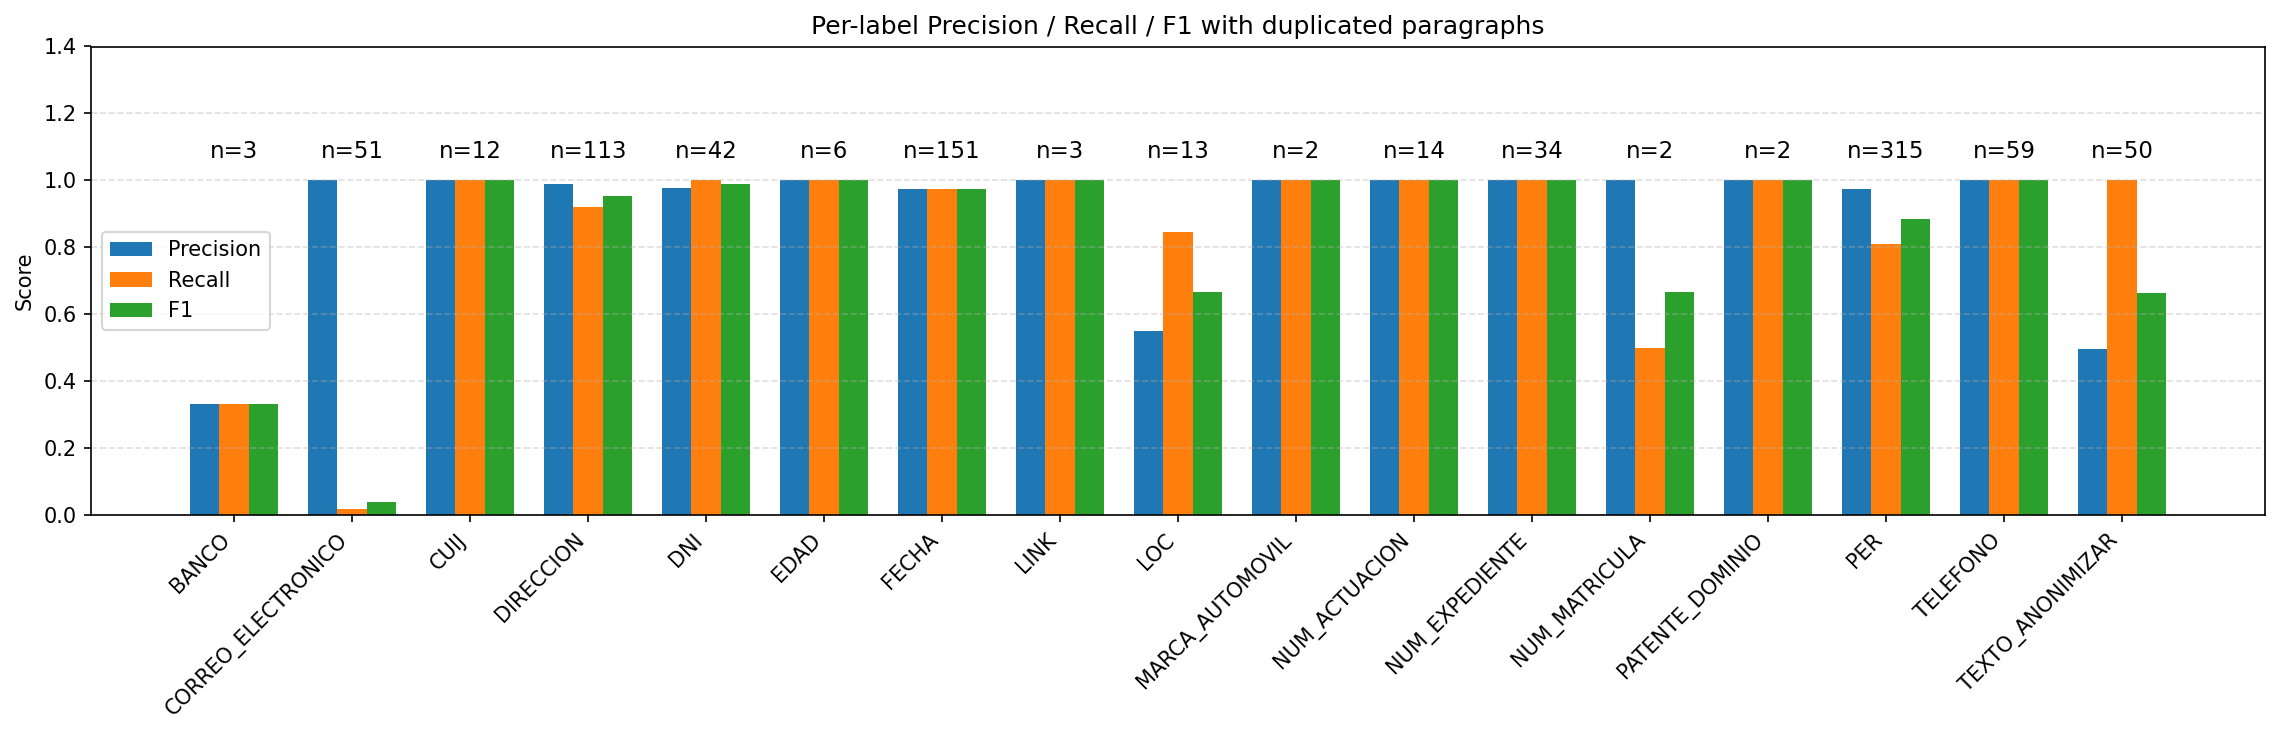

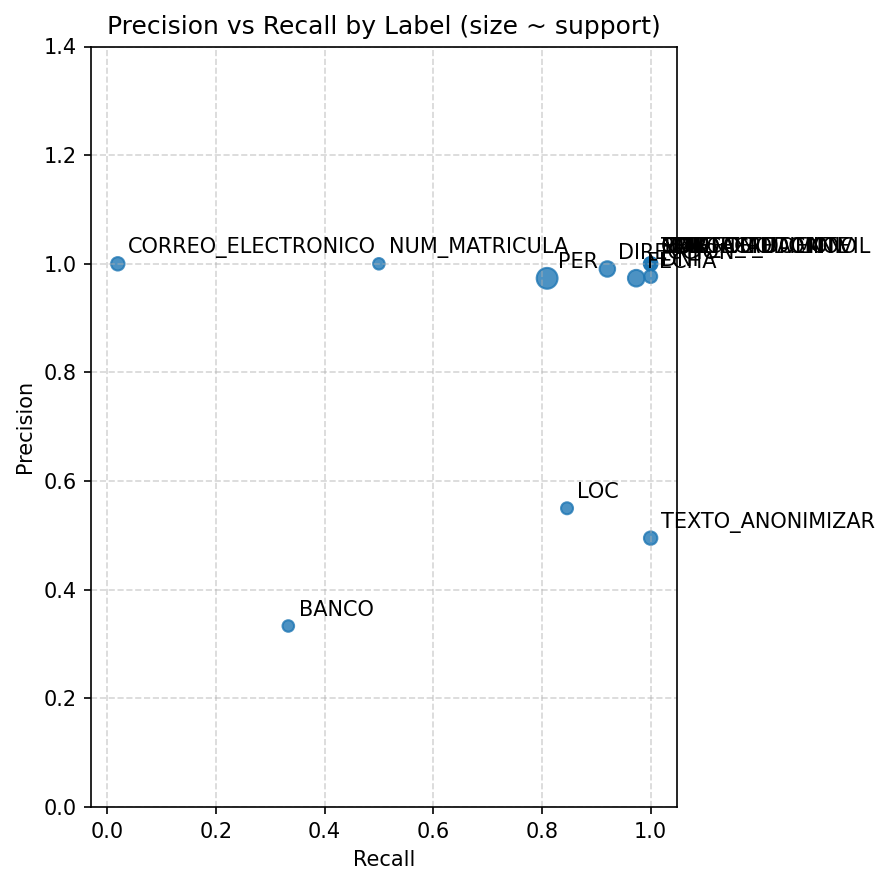

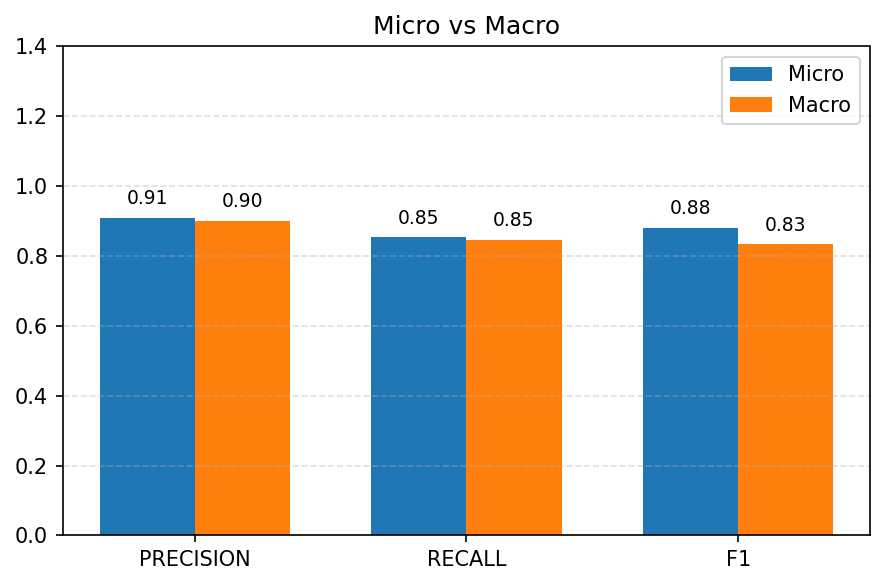

In [8]:
out_ner = metrics_per_entity_by_span(df)
plot_per_label_bars(out_ner, top=None, sort_by='support', aclaration_title = 'with duplicated paragraphs',alphabetical = True)
plot_pr_scatter(out_ner, min_support=1, annotate_top=None)
plot_micro_macro(out_ner)

In [ ]:
set(df.paragraph_id) - set(df_dropdup.paragraph_id)

set()

#### Without duplicated paragraph 

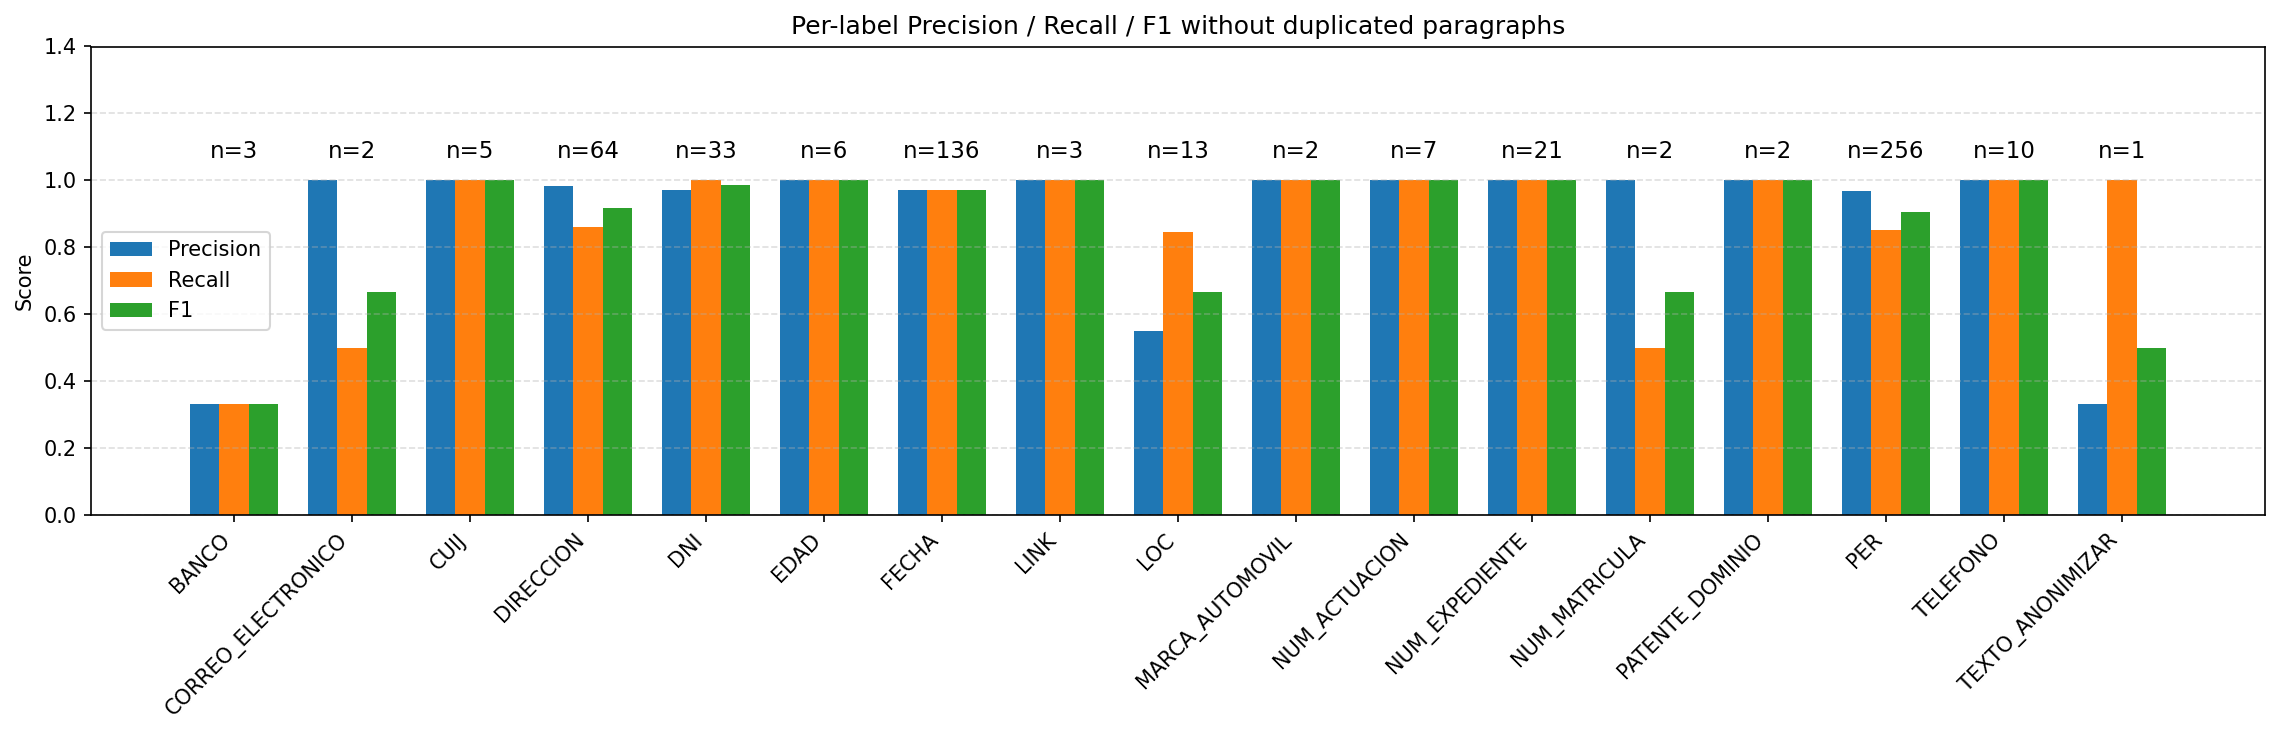

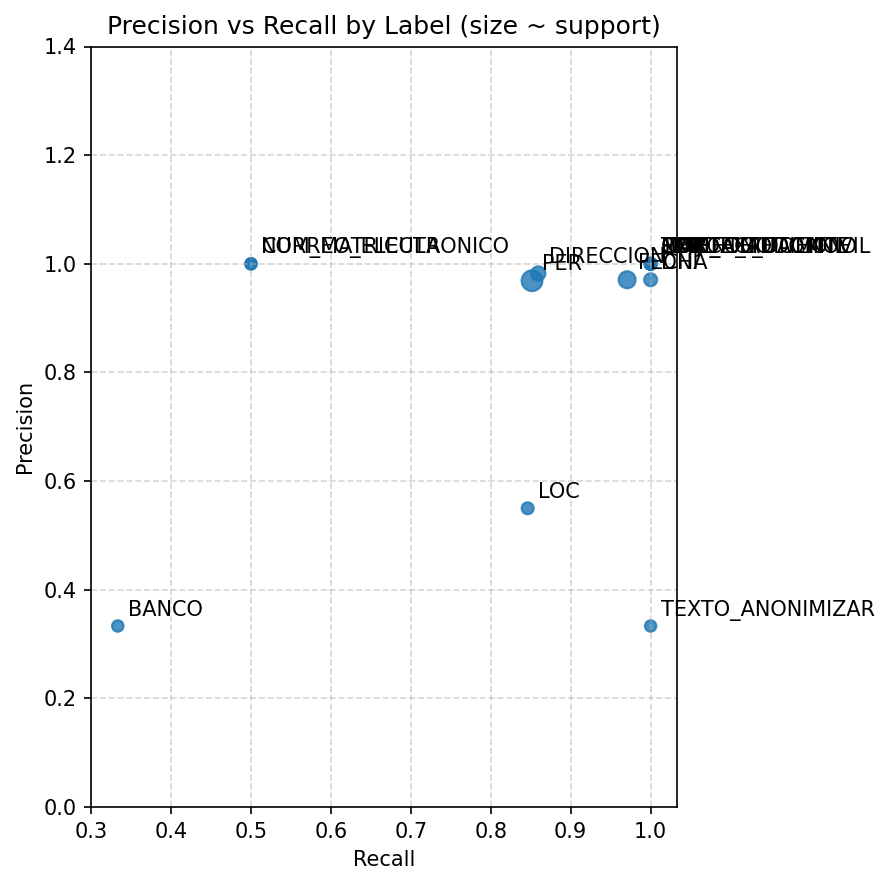

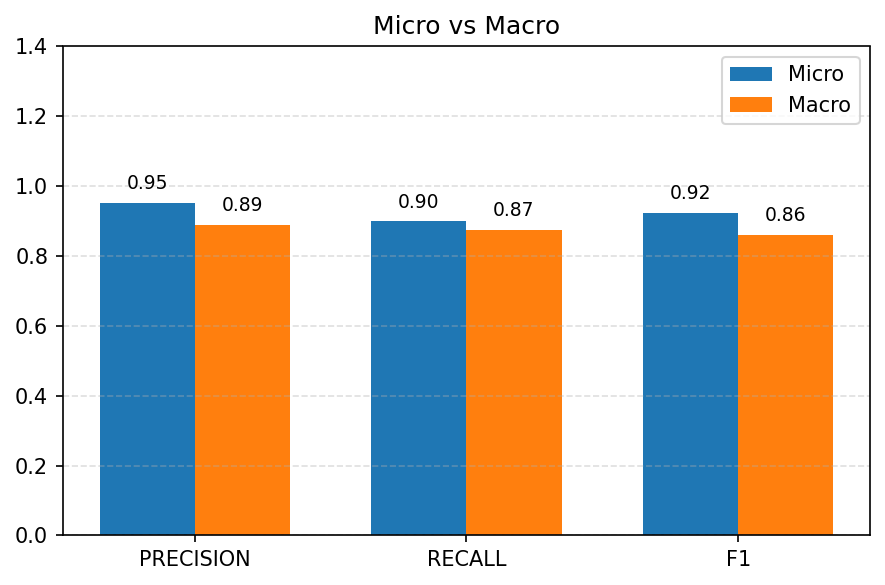

In [9]:
df_dropdup = df.drop_duplicates(subset='text_x', keep='first')
out = metrics_per_entity_by_span(df_dropdup)
plot_per_label_bars(out, top=None, sort_by='support', aclaration_title = 'without duplicated paragraphs',alphabetical = True)
plot_pr_scatter(out, min_support=1, annotate_top=None)
plot_micro_macro(out)

In [69]:
out['per_label'].keys()

dict_keys(['DIRECCION', 'TELEFONO', 'CORREO_ELECTRÓNICO', 'TEXTO_ANONIMIZAR', 'NUM_ACTUACION', 'NUM_EXPEDIENTE', 'PER', 'CUIJ', 'DNI', 'FECHA', 'CORREO_ELECTRONICO', 'LINK', 'LOC', 'EDAD', 'BANCO', 'NUM_MATRICULA', 'PATENTE_DOMINIO', 'MARCA_AUTOMOVIL'])

#### OpenAI + LangExtract metrics

##### Set docs from pedictions_openai

In [23]:
set(df_openai.prediction)

{'[]',
 "[{'label': 'BANCO', 'text': 'Banco Provincia de Buenos Aires', 'start_char': 1107, 'end_char': 1138, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}, {'label': 'DIRECCION', 'text': 'San Martín 137', 'start_char': 1202, 'end_char': 1216, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}]",
 "[{'label': 'CUIJ', 'text': 'DEB J-01-00023676-0/2020-1', 'start_char': 281, 'end_char': 307, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}]",
 "[{'label': 'CUIJ', 'text': 'IPP J-01-00017284-3/2022-0', 'start_char': 295, 'end_char': 321, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}]",
 "[{'label': 'CUIJ', 'text': 'IPP J-01-00017381-5/2020-0', 'start_char': 162, 'end_char': 188, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}]",
 "[{'label': 'CUIJ', 'text': 'IPP J-01-00059758-5/2018-0', 'start_char': 161, 'end_char': 187, 'attrs': {}, 'a

In [102]:
predictions

{'document-06.docx': [{'label': 'PER', 'text': 'GONZALEZ, MARCELO', 'start_char': 87, 'end_char': 104, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}, {'label': 'NUM_EXPEDIENTE', 'text': '31972/2018', 'start_char': 142, 'end_char': 152, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}, {'label': 'CUIJ', 'text': 'IPP J-01-00059758-5/2018-0', 'start_char': 161, 'end_char': 187, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}, {'label': 'NUM_ACTUACION', 'text': '12807225/2019', 'start_char': 203, 'end_char': 216, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}, {'label': 'NUM_EXPEDIENTE', 'text': '31.972/18', 'start_char': 351, 'end_char': 360, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}, {'label': 'FECHA', 'text': '13/03/2019', 'start_char': 368, 'end_char': 378, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match

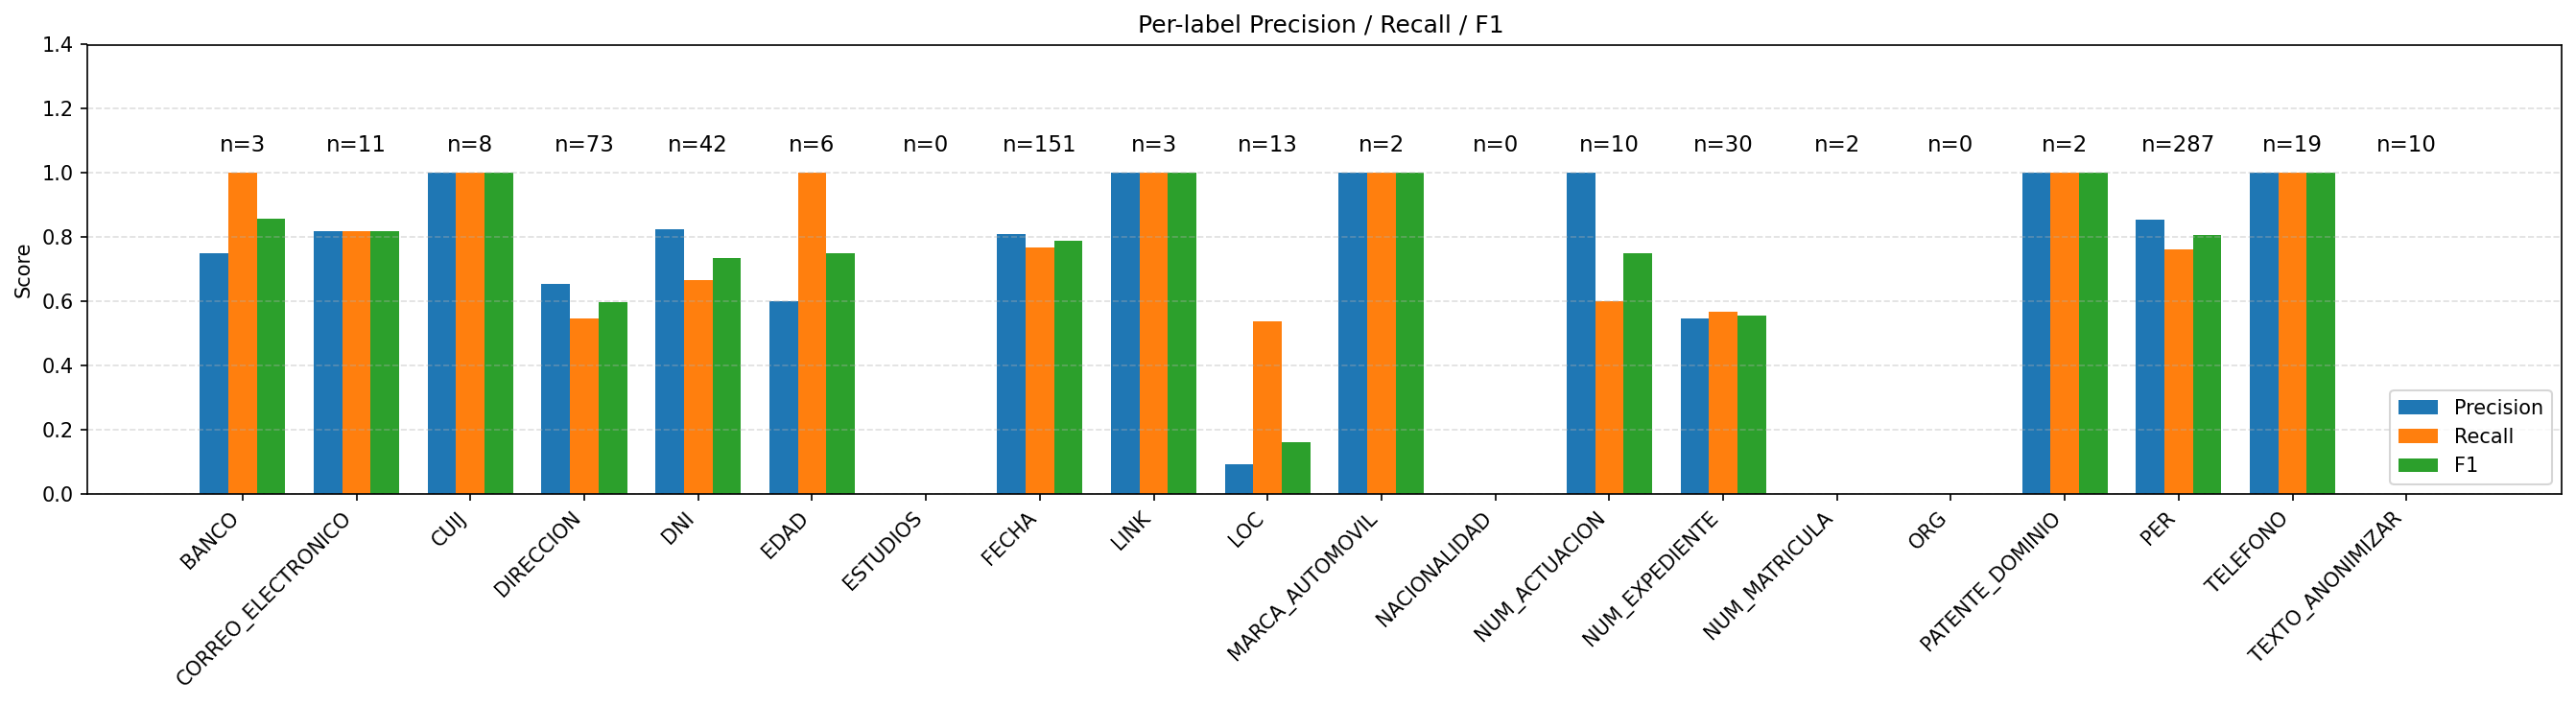

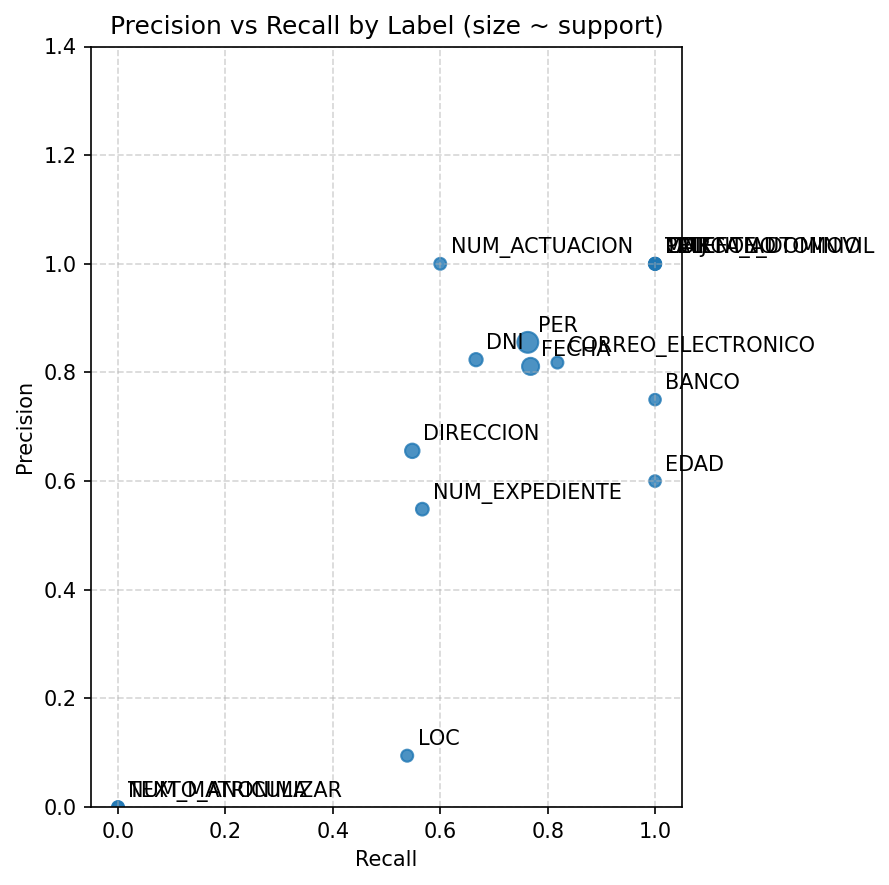

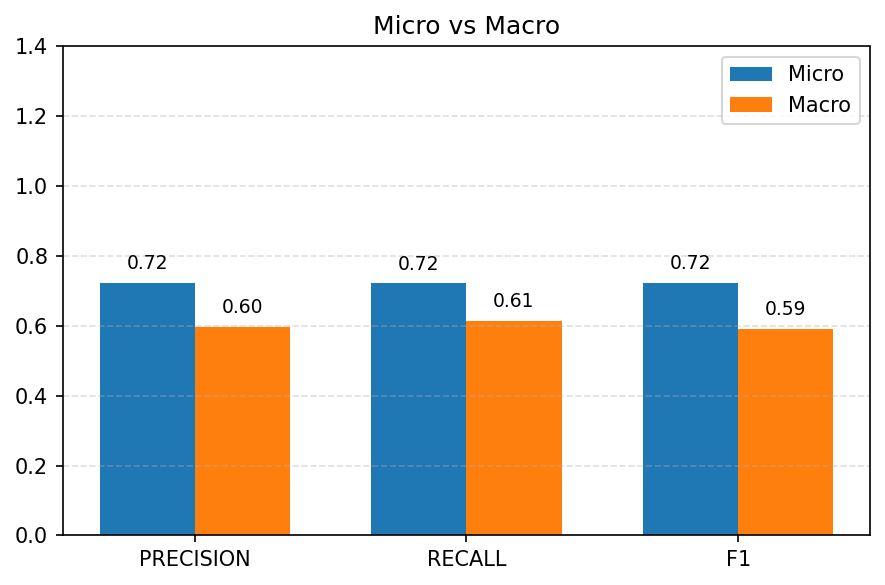

In [ ]:
df_openai = df.copy().rename(columns={'prediction':'NER_prediction'})

#for d in set(df.name):
#d = 'document-04.docx'
#preds = predictions[d]
#df_d = df_openai[df_openai['name'] == d].reset_index(drop=True)
#df_d['prediction'] = df_d.apply(lambda row: get_paragraph_predictions(row, predictions), axis=1)

def get_paragraph_predictions(row, predictions):
    preds = predictions.get(row['name'], [])
    return [
        p for p in preds
        if p['start_char'] >= row['start_char'] and p['end_char'] <= row['end_char']
    ]

df_openai['prediction'] = df_openai.apply(lambda row: get_paragraph_predictions(row, predictions), axis=1)


#errores = df_d[(df_d['validation'] != '[]') & (df_d['prediction'].apply(len) == 0)]

main_df = df_openai[df_openai.name == df_openai.doc]

out_openai = metrics_per_entity_by_span(main_df,is_openai=True)
plot_per_label_bars(out_openai, sort_by='support',alphabetical = True)
plot_pr_scatter(out_openai, min_support=1, annotate_top=18)
plot_micro_macro(out_openai)

In [ ]:
#df_openai.to_csv('df_openai.csv',index=False)

In [ ]:
#lambda x:  len([x.get('attrs', {}).get('aymurai_alt_start_char', None)for x in  eval(df_openai.validation.iloc[6]) ]) != len(set([x.get('attrs', {}).get('aymurai_alt_start_char', None)for x in  eval(df_openai.validation.iloc[6]) ]))

In [27]:
check = lambda doc:  len([x.get('attrs', {}).get('aymurai_alt_start_char', None)for x in  eval(doc) ]) != len(set([x.get('attrs', {}).get('aymurai_alt_start_char', None)for x in  eval(doc) ]))

In [28]:
df_openai.loc[df_openai.validation.map(lambda x: check(x))].shape

(39, 18)

In [98]:
main_df = df_openai[df_openai.name == df_openai.doc]

In [99]:
main_df.loc[main_df.duplicated(subset=['paragraph_id','name'])].sort_values(['paragraph_id','name'])

,text_x,NER_prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc,prediction
587,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-17 19:56:31-03:00,2025-08-24 18:44:19-03:00,3836b7607cde4c069dbe81fe75f218aa,4da9843514255b96b1090ad5dd685144,134602b55c4754e3987718fa7907011b,NaN,2025-08-24 18:44:21-03:00,document-06.docx,6,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",235,341,document-06.docx,[]
590,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-17 19:56:31-03:00,2025-08-24 18:44:19-03:00,c983618c6d35428d855af606ed1905ef,9dfa3cb436a85f6fba380b1d82e711b8,134602b55c4754e3987718fa7907011b,NaN,2025-08-22 20:51:16-03:00,document-07.docx,7,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",287,393,document-07.docx,[]
583,CUIJ: IPP J-01-00059758-5/2018-0,"[{""start"": 1, ""end"": 3, ""label"": ""CUIJ"", ""text...","[{""text"": ""IPP J-01-00059758-5/2018-0"", ""start...",1b20a1be99cb5c4684f16cf1f70cf5b6,2025-08-17 19:56:27-03:00,2025-08-24 18:44:19-03:00,0ce4f7bf96f546dba2804f3df31774e4,4da9843514255b96b1090ad5dd685144,1b20a1be99cb5c4684f16cf1f70cf5b6,NaN,2025-08-24 18:44:21-03:00,document-06.docx,3,CUIJ: IPP J-01-00059758-5/2018-0,155,187,document-06.docx,"[{'label': 'CUIJ', 'text': 'IPP J-01-00059758-..."
586,CUIJ: IPP J-01-00059758-5/2018-0,"[{""start"": 1, ""end"": 3, ""label"": ""CUIJ"", ""text...","[{""text"": ""IPP J-01-00059758-5/2018-0"", ""start...",1b20a1be99cb5c4684f16cf1f70cf5b6,2025-08-17 19:56:27-03:00,2025-08-24 18:44:19-03:00,e556f64d73774e74b35b80af3116b086,9dfa3cb436a85f6fba380b1d82e711b8,1b20a1be99cb5c4684f16cf1f70cf5b6,NaN,2025-08-22 20:51:16-03:00,document-07.docx,4,CUIJ: IPP J-01-00059758-5/2018-0,207,239,document-07.docx,"[{'label': 'CUIJ', 'text': 'IPP J-01-00059758-..."
437,1. HOMOLOGAR EL ACUERDO DE AVENIMIENTO formula...,"[{""start"": 14, ""end"": 17, ""label"": ""PER"", ""tex...","[{""text"": ""ELVIS JUNIOR GOMEZ"", ""start_char"": ...",2037ab0ad1b7518ca04b515022d16f6b,2025-08-27 01:01:22-03:00,2025-08-27 02:56:14-03:00,03a2a2a41ff54c2cbee5630606f843f1,6a7d2422da6a5852b68a7bee678d1aae,2037ab0ad1b7518ca04b515022d16f6b,NaN,2025-08-27 02:56:14-03:00,document-04.docx,128,1. HOMOLOGAR EL ACUERDO DE AVENIMIENTO formula...,33695,34714,document-04.docx,"[{'label': 'PER', 'text': 'ELVIS JUNIOR GOMEZ'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,"Defensora Oficial: María Marta Sormani, titula...",[],"[{""text"": ""Mar\u00eda Marta Sormani"", ""start_c...",f262cb76388e50afa4d75670e978b3e4,2025-08-17 19:56:37-03:00,2025-08-24 18:44:20-03:00,78c106b8e3214555ae52612bc3081d48,4da9843514255b96b1090ad5dd685144,f262cb76388e50afa4d75670e978b3e4,NaN,2025-08-24 18:44:21-03:00,document-06.docx,15,"Defensora Oficial: María Marta Sormani, titula...",926,1015,document-06.docx,"[{'label': 'PER', 'text': 'María Marta Sormani..."
622,"Defensora Oficial: María Marta Sormani, titula...",[],"[{""text"": ""Mar\u00eda Marta Sormani"", ""start_c...",f262cb76388e50afa4d75670e978b3e4,2025-08-17 19:56:37-03:00,2025-08-24 18:44:20-03:00,b3ac9ef113994d2ab3c7a8eea09c8d8e,9dfa3cb436a85f6fba380b1d82e711b8,f262cb76388e50afa4d75670e978b3e4,NaN,2025-08-22 20:51:16-03:00,document-07.docx,16,"Defensora Oficial: María Marta Sormani, titula...",828,917,document-07.docx,"[{'label': 'PER', 'text': 'María Marta Sormani..."
453,5. ENVIAR el email correspondiente al Servicio...,"[{""start"": 15, ""end"": 18, ""label"": ""PER"", ""tex...","[{""text"": ""ELVIS JUNIOR GOMEZ"", ""start_char"": ...",fa3b25f7c3ec59cc8bbcb1ec16d72e18,2025-08-27 01:01:25-03:00,2025-08-27 02:56:14-03:00,5a9d349bff36

In [ ]:
df_openai.loc[df_openai.duplicated(subset=['paragraph_id','name'])].sort_values(['paragraph_id','name'])

,text_x,NER_prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc,prediction
144,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,3836b7607cde4c069dbe81fe75f218aa,4da9843514255b96b1090ad5dd685144,134602b55c4754e3987718fa7907011b,NaN,2025-08-24 18:44:21-03:00,document-06.docx,7,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",287,393,document-07.docx,"[{'label': 'NUM_EXPEDIENTE', 'text': '31.972/1..."
587,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-17 19:56:31-03:00,2025-08-24 18:44:19-03:00,3836b7607cde4c069dbe81fe75f218aa,4da9843514255b96b1090ad5dd685144,134602b55c4754e3987718fa7907011b,NaN,2025-08-24 18:44:21-03:00,document-06.docx,6,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",235,341,document-06.docx,[]
588,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-17 19:56:31-03:00,2025-08-24 18:44:19-03:00,3836b7607cde4c069dbe81fe75f218aa,4da9843514255b96b1090ad5dd685144,134602b55c4754e3987718fa7907011b,NaN,2025-08-24 18:44:21-03:00,document-06.docx,7,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",287,393,document-07.docx,"[{'label': 'NUM_EXPEDIENTE', 'text': '31.972/1..."
146,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,c983618c6d35428d855af606ed1905ef,9dfa3cb436a85f6fba380b1d82e711b8,134602b55c4754e3987718fa7907011b,NaN,2025-08-22 20:51:16-03:00,document-07.docx,7,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",287,393,document-07.docx,[]
589,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-17 19:56:31-03:00,2025-08-24 18:44:19-03:00,c983618c6d35428d855af606ed1905ef,9dfa3cb436a85f6fba380b1d82e711b8,134602b55c4754e3987718fa7907011b,NaN,2025-08-22 20:51:16-03:00,document-07.docx,6,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",235,341,document-06.docx,"[{'label': 'NUM_ACTUACION', 'text': '12508563/..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
621,"Defensora Oficial: María Marta Sormani, titula...",[],"[{""text"": ""Mar\u00eda Marta Sormani"", ""start_c...",f262cb76388e50afa4d75670e978b3e4,2025-08-17 19:56:37-03:00,2025-08-24 18:44:20-03:00,b3ac9ef113994d2ab3c7a8eea09c8d8e,9dfa3cb436a85f6fba380b1d82e711b8,f262cb76388e50afa4d75670e978b3e4,NaN,2025-08-22 20:51:16-03:00,document-07.docx,15,"Defensora Oficial: María Marta Sormani, titula...",926,1015,document-06.docx,"[{'label': 'PER', 'text': 'MARCELO GONZALEZ', ..."
622,"Defensora Oficial: María Marta Sormani, titula...",[],"[{""text"": ""Mar\u00eda Marta Sormani"", ""start_c...",f262cb76388e50afa4d75670e978b3e4,2025-08-17 19:56:37-03:00,2025-08-24 18:44:20-03:00,b3ac9ef113994d2ab3c7a8eea09c8d8e,9dfa3cb436a85f6fba380b1d82e711b8,f262cb76388e50afa4d75670e978b3e4,NaN,2025-08-22 20:51:16-03:00,document-07.docx,16,"Defensora Oficial: María Marta Sormani, titula...",828,917,document-07.docx,"[{'label': 'PER', 'text': 'María Marta Sormani..."
453,5. ENVIAR el email correspondiente al Servicio...,"[{""start"": 15, ""end"": 18, ""label"": ""PER"", ""tex...","[{""text"": ""ELVIS JUNIOR GOMEZ"", ""start_char"": ...",fa3b25f7c3ec

In [19]:
df_openai= pd.read_csv('df_openai.csv')
df_openai

,text_x,NER_prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc,prediction
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,148,233,document-02.docx,[]
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,62,147,document-08.docx,[]
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,2c74793eac2341969aa3dcce7950f43b,6a7d2422da6a5852b68a7bee678d1aae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 02:56:14-03:00,document-04.docx,0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,0,85,document-04.docx,[]
3,ANTECEDENTES,[],[],adee5f8144eb5e78abb3c56121e906cd,2025-08-08 19:40:02-03:00,2025-08-08 19:40:45-03:00,b31e11b3cff24069b7cf3faa666fbdec,0aec75365ad0511698f72bacb8b88212,adee5f8144eb5e78abb3c56121e906cd,NaN,2025-08-22 19:41:55-03:00,document-03.docx,9,ANTECEDENTES,857,869,document-03.docx,[]
4,ANTECEDENTES,[],[],adee5f8144eb5e78abb3c56121e906cd,2025-08-08 19:40:02-03:00,2025-08-08 19:40:45-03:00,4abeb6f8ff3340cb99cfe61b16276012,518a7f34ad865b91ad95d954093f091a,adee5f8144eb5e78abb3c56121e906cd,NaN,2025-08-22 21:20:53-03:00,document-02.docx,9,ANTECEDENTES,725,737,document-02.docx,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,"V. NOTIFÍQUESE al imputado, a la señora Defens...",[],[],198d94ca38b75b6f935662ee9b75f8ac,2025-08-17 19:58:50-03:00,2025-08-24 18:44:21-03:00,476385305c5e4fb4a0d511c941d82118,4da9843514255b96b1090ad5dd685144,198d94ca38b75b6f935662ee9b75f8ac,NaN,2025-08-24 18:44:21-03:00,document-06.docx,119,"V. NOTIFÍQUESE al imputado, a la señora Defens...",33861,34108,document-06.docx,[]
591,VI. Una vez agotada la instancia para presenta...,[],[],eb36c10d83dc52ceab003fe85ad31193,2025-08-17 19:58:51-03:00,2025-08-24 18:44:21-03:00,33fa5e248d0a432186ccfa7a8bb2131d,4da9843514255b96b1090ad5dd685144,eb36c10d83dc52ceab003fe85ad31193,NaN,2025-08-24 18:44:21-03:00,document-06.docx,120,VI. Una vez agotada la instancia para presenta...,34109,34364,document-06.docx,[]
592,VII. LÍBRENSE los oficios pertinentes a fin de...,[],[],e438a7dd79465143ae0e9e547ff13538,2025-08-17 19:58:55-03:00,2025-08-24 18:44:21-03:00,f404245d14bc49dd9b2a105a6de10f7a,4da9843514255b96b1090ad5dd685144,e438a7dd79465143ae0e9e547ff13538,NaN,2025-08-24 18:44:21-03:00,document-06.docx,121,VII. LÍBRENSE los oficios pertinentes a fin de...,34365,34582,document-06.docx,[]
593,VIII. DEJAR CONSTANCIA de la posible constatac...,[],[],5f8a5f921633538384b61633c3d12128,2025-08-17 19:58:55-03:00,2025-08-24 18:44:21-03:00,ec214164132149f7814e7957d90a1026,4da9843514255b96b1090ad5dd685144,5f8a5f921633538384b61633c3d12128,NaN,2025-08-24 18:44:21-03:00,document-06.docx,122,VIII. DEJAR CONSTANCIA de la posible constatac...,34583,34816,document-06.docx,[]


In [11]:
df_openai.columns

Index(['text_x', 'NER_prediction', 'validation', 'id_x', 'created_at_x',
       'updated_at', 'id_y', 'document_id', 'paragraph_id', 'order',
       'created_at_y', 'name', 'paragraph_position', 'text_y', 'start_char',
       'end_char', 'doc', 'prediction'],
      dtype='object')

In [35]:
def metrics_per_entity_by_span(df, is_openai = False):
    # acumula TP/FP/FN por entidad (label)
    counts = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})

    for i in range(len(df)):
        # cada celda puede ser una lista de dicts; si falla, lista vacía
        try:
            val_list = eval(df.validation.iloc[i])
        except:
            val_list = []
        try:
            pred_list = eval(df.prediction.iloc[i])
        except:
            try:
                pred_list = df.prediction.iloc[i]
            except:
                pred_list = []
            
        # sets de spans por label: {(start, end), ...}
        val_spans = defaultdict(set)
        pred_spans = defaultdict(set)
        start_char = int(df.start_char.iloc[i])

        # VALIDATION (val)
        for v in (val_list or []):
            if not isinstance(v, dict):
                continue
            lab = (v.get('attrs', {}).get('aymurai_label', None)) or v.get('label', None)
            lab = lab.replace('CORREO_ELECTRÓNICO','CORREO_ELECTRONICO')
            s = v.get('attrs', {}).get('aymurai_alt_start_char', None)
            e = v.get('attrs', {}).get('aymurai_alt_end_char', None)
            if lab is not None and s is not None and e is not None:
                val_spans[lab].add((int(s), int(e)))
                #print('validation:')
                #print(lab, s, e)
        #print('val_spans: ', val_spans)

        # PREDICTIONS
        for p in (pred_list or []):
            if not isinstance(p, dict):
                continue
            lab = p.get('attrs', {}).get('aymurai_label', None) or p.get('label', None)
            lab = lab.replace('CORREO_ELECTRÓNICO','CORREO_ELECTRONICO')
            s = p.get('attrs', {}).get('aymurai_alt_start_char', None) or p.get('start_char', None)
            e = p.get('attrs', {}).get('aymurai_alt_end_char', None) or p.get('end_char', None)
            if lab is not None and s is not None and e is not None:
                if is_openai:
                    pred_spans[lab].add((int(s)-start_char, int(e)- start_char))
                else:
                    pred_spans[lab].add((int(s), int(e)))

                #print('prediction:')
                #print(lab, s, e)
        #print('pred_spans: ', pred_spans)
        # actualizar TP/FP/FN por label en esta fila
        for lab in set(list(val_spans.keys()) + list(pred_spans.keys())):
            vs = val_spans.get(lab, set())
            ps = pred_spans.get(lab, set())
            tp = len(ps & vs)
            fp = len(ps - vs)
            fn = len(vs - ps)
            counts[lab]['tp'] += tp
            counts[lab]['fp'] += fp
            counts[lab]['fn'] += fn

    # calcular métricas por label + micro/macro
    out = {'per_label': {}, 'micro': {}, 'macro': {}}
    micro_tp = micro_fp = micro_fn = 0

    for lab, c in counts.items():
        tp, fp, fn = c['tp'], c['fp'], c['fn']
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        support   = tp + fn  # cantidad de entidades de referencia (validation) para ese label
        out['per_label'][lab] = {'precision': precision, 'recall': recall, 'f1': f1, 'support': support}
        micro_tp += tp; micro_fp += fp; micro_fn += fn

    # micro
    micro_p = micro_tp / (micro_tp + micro_fp) if (micro_tp + micro_fp) > 0 else 0.0
    micro_r = micro_tp / (micro_tp + micro_fn) if (micro_tp + micro_fn) > 0 else 0.0
    micro_f = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) > 0 else 0.0
    out['micro'] = {'precision': micro_p, 'recall': micro_r, 'f1': micro_f, 'support': micro_tp + micro_fn}

    # macro (promedio simple entre labels presentes)
    if out['per_label']:
        L = len(out['per_label'])
        macro_p = sum(m['precision'] for m in out['per_label'].values()) / L
        macro_r = sum(m['recall']    for m in out['per_label'].values()) / L
        macro_f = sum(m['f1']        for m in out['per_label'].values()) / L
    else:
        macro_p = macro_r = macro_f = 0.0
    out['macro'] = {'precision': macro_p, 'recall': macro_r, 'f1': macro_f}

    return out


### Compare models

In [113]:
len(doc_paragraphs['document-04.docx'])

136

# Chequear parrafos

In [115]:
[{doc:len(pars)} for doc, pars in doc_paragraphs.items()]

[{'document-06.docx': 125}, {'document-07.docx': 65}, {'document-02.docx': 67}, {'document-03.docx': 55}, {'document-04.docx': 136}, {'document-08.docx': 92}]

In [116]:
main_df.groupby('name').count().paragraph_id

name
document-02.docx     69
document-03.docx     55
document-04.docx    157
document-06.docx    140
document-07.docx     80
document-08.docx     94
Name: paragraph_id, dtype: int64

['2021 - Año del Bicentenario de la Universidad de Buenos Aires', 'JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVENCIONAL Y DE FALTAS N°10 SECRETARIA N°19', 'PINZON, HECTOR EZEQUIEL SOBRE 53 BIS - AGRAVANTES (CONDUCTAS DESCRIPTAS EN LOS ARTÍCULOS 51, 52 Y 53)', 'Número: DEB 18140/2020-1', 'CUIJ: DEB J-01-00023676-0/2020-1', 'Actuación Nro: 1785766/2021', 'FUNDAMENTOS CONDENA', 'Condena al acusado a la pena principal de tareas comunitarias por diez días, más la pena accesoria de instrucciones especiales consistentes en la realización del taller "dispositivo de abordaje a las nociones de perspectiva de género" de la Secretaría de Ejecución y Control de Sanciones, por la contravención de acoso sexual basada en la desigualdad de género (art. 26, 53, 54 LPC, 69 inc. 3 CC, y 26 inc. a.1) Ley 26.485)', 'Buenos Aires, 31 de agosto de 2021.', 'ANTECEDENTES', 'El día 24 de agosto de 2021 llevé adelante el juicio oral y público, en el cual se juzgó a HECTOR EZEQUIEL PINZON el hecho que le fue atrib

In [36]:
import numpy as np
def compare_models(out_openai, out_ner, metric = 'F1',sort_by="support", top=None):
    df_o = _metrics_to_df(out_openai).set_index("label")
    df_n = _metrics_to_df(out_ner).set_index("label")
    
    # mergeando
    df = df_o.join(df_n, lsuffix="_openai", rsuffix="_ner", how="outer").fillna(0)

    # eliminar labels con soporte 0 en ambos
    df = df[(df["support_openai"] > 0) | (df["support_ner"] > 0)]

    # ordenar
    if sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=False)
    if top:
        df = df.head(top)

    labels = df.index.tolist()
    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(max(6,len(labels)*0.9),5),dpi=150)
    plt.grid(alpha = 0.5, linestyle = 'dashed')  
    if metric == 'F1': 
        bars1 = ax.bar(x - width/2, df["f1_openai"], width, color="darkgreen",label="OpenAI+LangExtract F1",edgecolor='black',linewidth = 1)
        bars2 = ax.bar(x + width/2, df["f1_ner"], width,color = "goldenrod" , label="NER F1",edgecolor='black',linewidth = 1)
        ax.set_title("Comparación F1 por entidad")
        ax.set_ylabel("F1")

    elif metric == 'recall':
        bars1 = ax.bar(x - width/2, df["recall_openai"], width, color="darkgreen",label="OpenAI+LangExtract recall",edgecolor='black',linewidth = 1)
        bars2 = ax.bar(x + width/2, df["recall_ner"], width,color = "goldenrod" , label="NER recall",edgecolor='black',linewidth = 1)
        ax.set_title("Comparación recall por entidad")
        ax.set_ylabel("recall")

    elif metric == 'precision':        
        bars1 = ax.bar(x - width/2, df["precision_openai"], width, color="darkgreen",label="OpenAI+LangExtract precision",edgecolor='black',linewidth = 1)
        bars2 = ax.bar(x + width/2, df["precision_ner"], width,color = "goldenrod" , label="NER precision",edgecolor='black',linewidth = 1)
        ax.set_title("Comparación precision por entidad")
        ax.set_ylabel("precision")

    # anotar supports
    for i, (b1, b2) in enumerate(zip(bars1, bars2)):
        s1 = int(df.iloc[i]["support_openai"])
        s2 = int(df.iloc[i]["support_ner"])
        h = np.max([b1.get_height(),b2.get_height()])
        ax.text(b1.get_x() + b1.get_width(), h+0.02, f"n={s1}", 
                ha="center", va="bottom", fontsize=14, color="black")

        #ax.text(b2.get_x() + b2.get_width()/2, h+0.02, f"n={s2}", 
        #        ha="center", va="bottom", fontsize=14, color="grey", rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.legend()
    ax.set_ylim(0, 1.2)
    plt.tight_layout()
    plt.show()
    
    return df.reset_index()



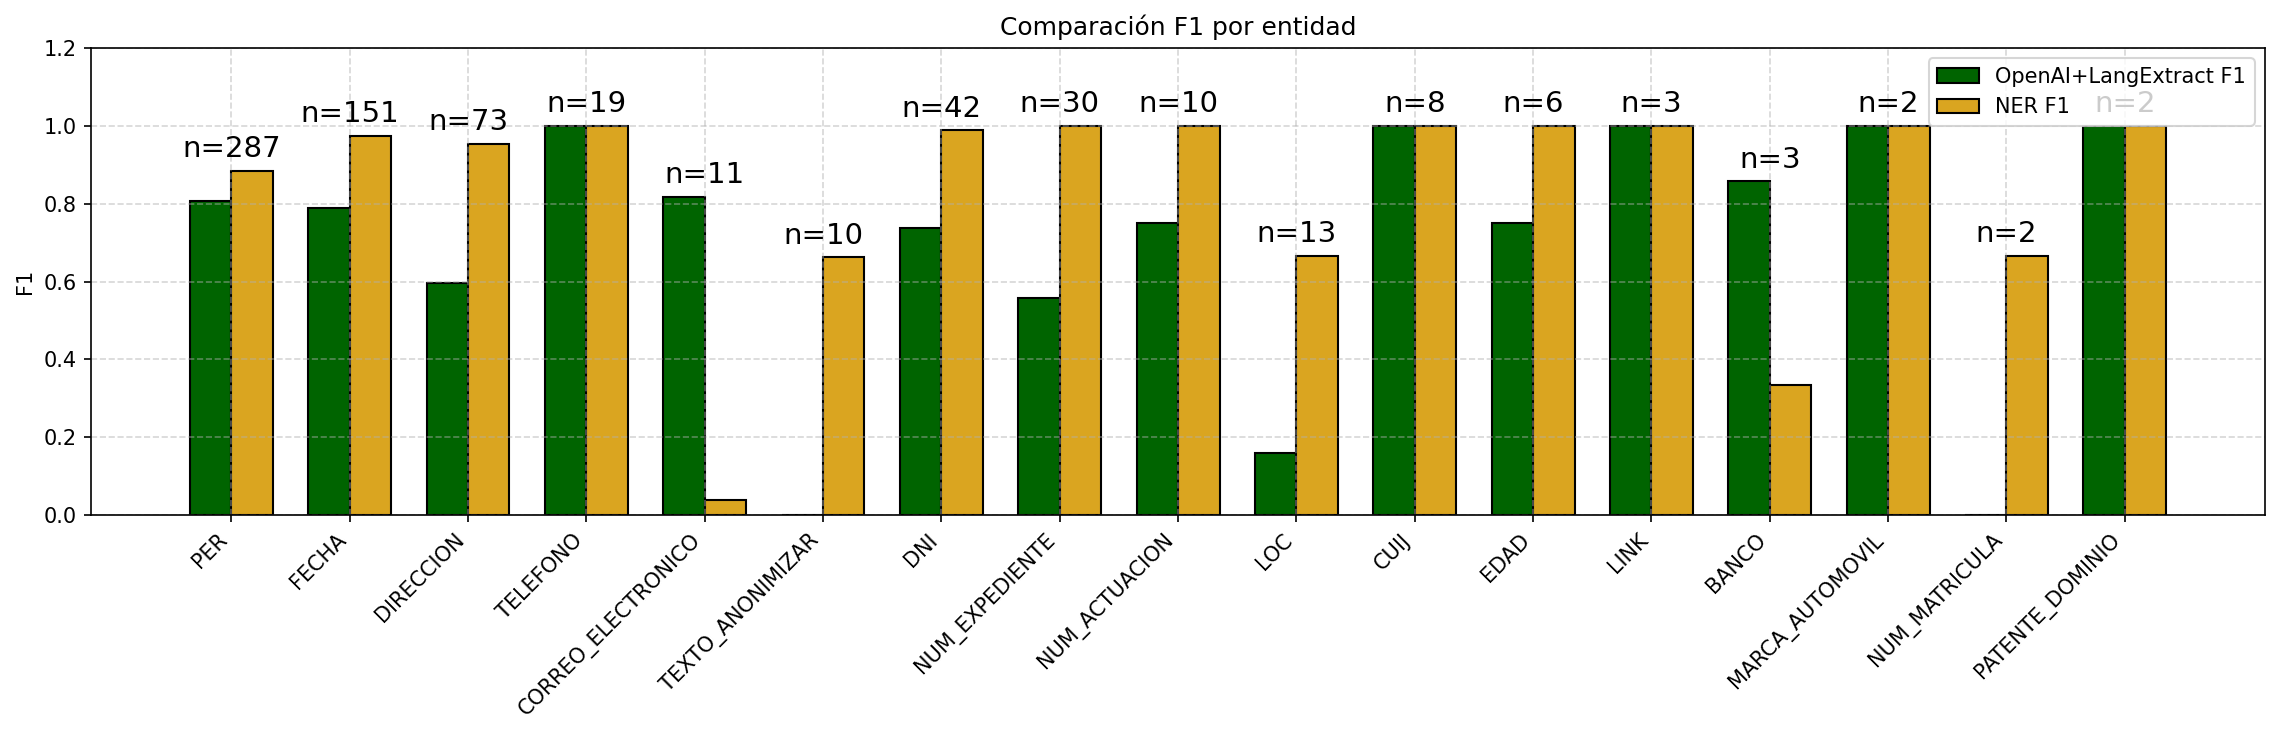

,label,precision_openai,recall_openai,f1_openai,support_openai,precision_ner,recall_ner,f1_ner,support_ner
0,PER,0.855469,0.763066,0.806630,287,0.973282,0.809524,0.883882,315.0
1,FECHA,0.811189,0.768212,0.789116,151,0.973510,0.973510,0.973510,151.0
2,DIRECCION,0.655738,0.547945,0.597015,73,0.990476,0.920354,0.954128,113.0
3,TELEFONO,1.000000,1.000000,1.000000,19,1.000000,1.000000,1.000000,59.0
4,CORREO_ELECTRONICO,0.818182,0.818182,0.818182,11,1.000000,0.019608,0.038462,51.0
5,TEXTO_ANONIMIZAR,0.000000,0.000000,0.000000,10,0.495050,1.000000,0.662252,50.0
6,DNI,0.823529,0.666667,0.736842,42,0.976744,1.000000,0.988235,42.0
7,NUM_EXPEDIENTE,0.548387,0.566667,0.557377,30,1.000000,1.000000,1.000000,34.0
8,NUM_ACTUACION,1.000000,0.600000,0.750000,10,1.000000,1.000000,1.000000,14.0
9,LOC,0.094595,0.538462,0.160920,13,0.550000,0.846154,0.666667,13.0


In [101]:
compare_models(out_openai, out_ner,metric = 'F1', sort_by="support_ner")

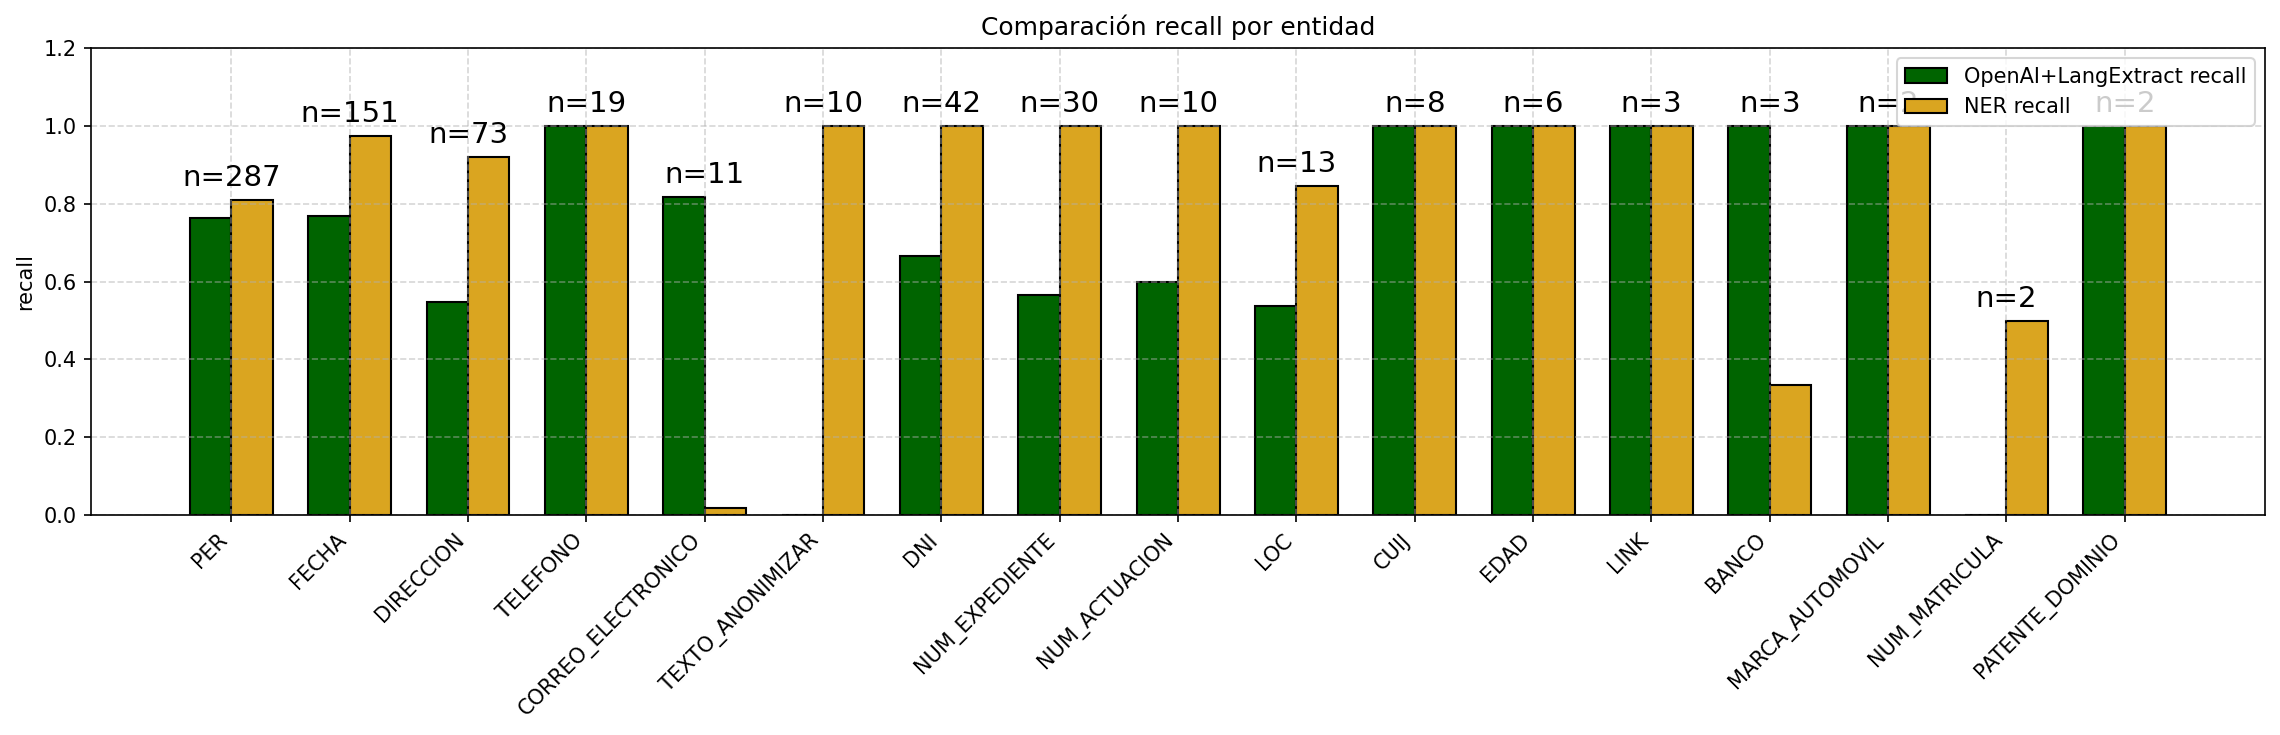

,label,precision_openai,recall_openai,f1_openai,support_openai,precision_ner,recall_ner,f1_ner,support_ner
0,PER,0.855469,0.763066,0.806630,287,0.973282,0.809524,0.883882,315.0
1,FECHA,0.811189,0.768212,0.789116,151,0.973510,0.973510,0.973510,151.0
2,DIRECCION,0.655738,0.547945,0.597015,73,0.990476,0.920354,0.954128,113.0
3,TELEFONO,1.000000,1.000000,1.000000,19,1.000000,1.000000,1.000000,59.0
4,CORREO_ELECTRONICO,0.818182,0.818182,0.818182,11,1.000000,0.019608,0.038462,51.0
5,TEXTO_ANONIMIZAR,0.000000,0.000000,0.000000,10,0.495050,1.000000,0.662252,50.0
6,DNI,0.823529,0.666667,0.736842,42,0.976744,1.000000,0.988235,42.0
7,NUM_EXPEDIENTE,0.548387,0.566667,0.557377,30,1.000000,1.000000,1.000000,34.0
8,NUM_ACTUACION,1.000000,0.600000,0.750000,10,1.000000,1.000000,1.000000,14.0
9,LOC,0.094595,0.538462,0.160920,13,0.550000,0.846154,0.666667,13.0


In [117]:
compare_models(out_openai, out_ner,metric = 'recall',sort_by="support_ner")

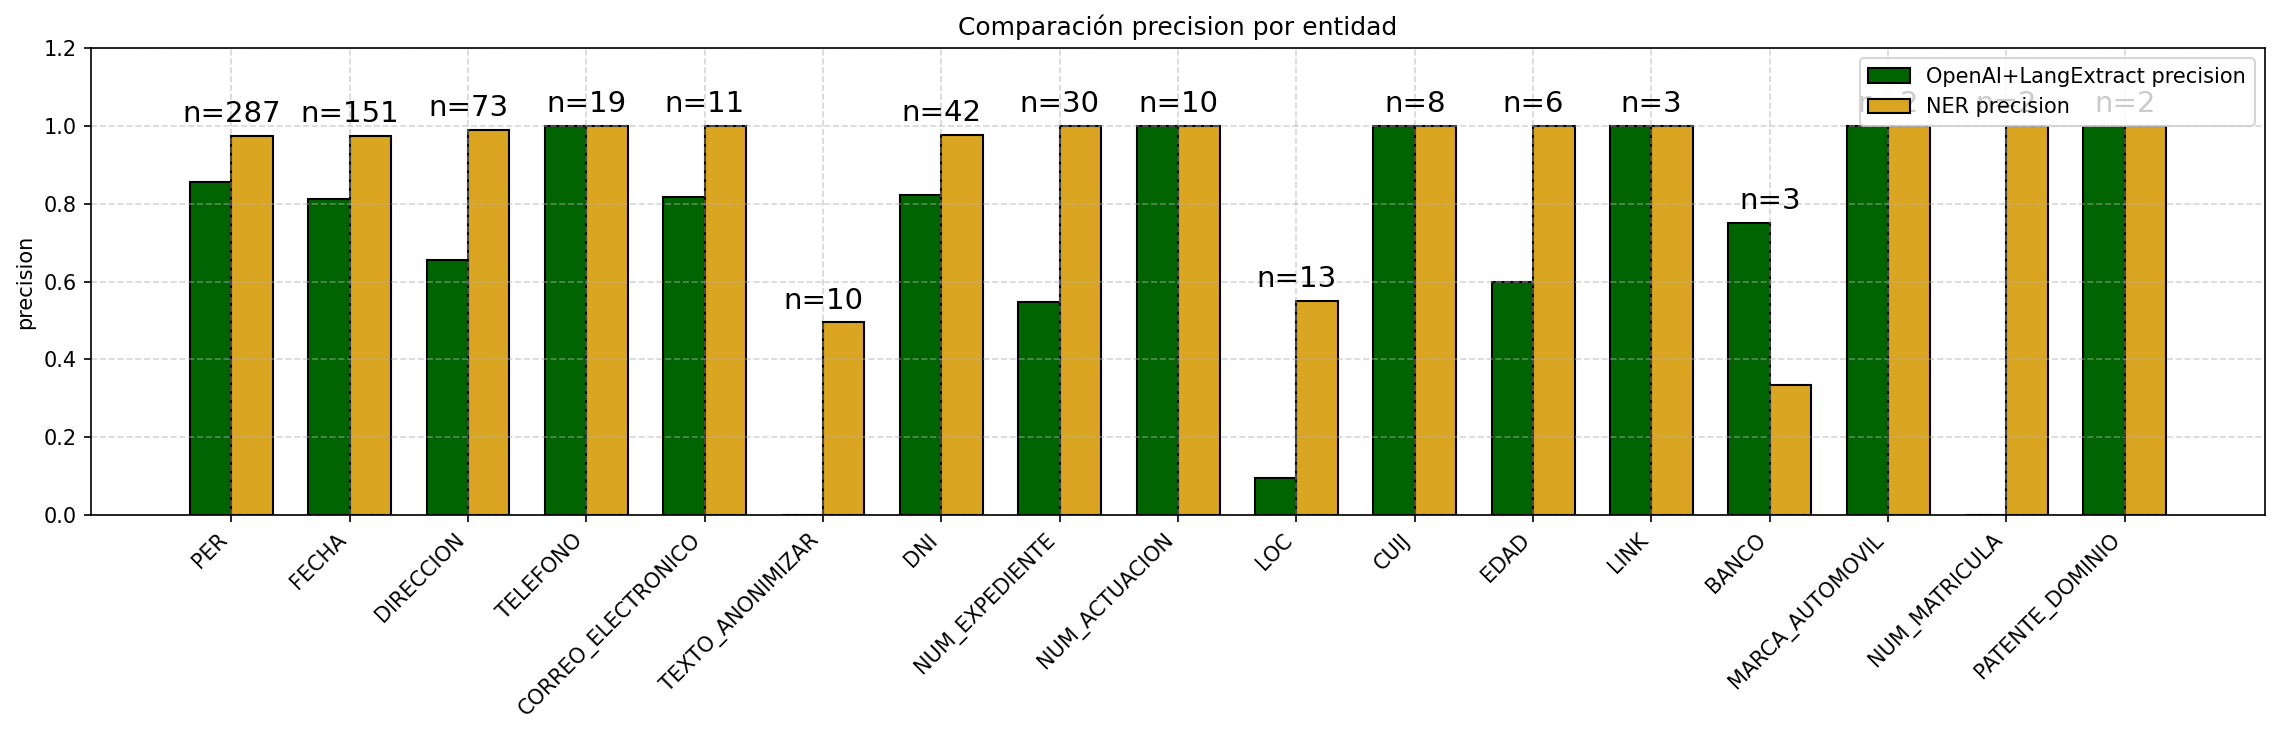

,label,precision_openai,recall_openai,f1_openai,support_openai,precision_ner,recall_ner,f1_ner,support_ner
0,PER,0.855469,0.763066,0.806630,287,0.973282,0.809524,0.883882,315.0
1,FECHA,0.811189,0.768212,0.789116,151,0.973510,0.973510,0.973510,151.0
2,DIRECCION,0.655738,0.547945,0.597015,73,0.990476,0.920354,0.954128,113.0
3,TELEFONO,1.000000,1.000000,1.000000,19,1.000000,1.000000,1.000000,59.0
4,CORREO_ELECTRONICO,0.818182,0.818182,0.818182,11,1.000000,0.019608,0.038462,51.0
5,TEXTO_ANONIMIZAR,0.000000,0.000000,0.000000,10,0.495050,1.000000,0.662252,50.0
6,DNI,0.823529,0.666667,0.736842,42,0.976744,1.000000,0.988235,42.0
7,NUM_EXPEDIENTE,0.548387,0.566667,0.557377,30,1.000000,1.000000,1.000000,34.0
8,NUM_ACTUACION,1.000000,0.600000,0.750000,10,1.000000,1.000000,1.000000,14.0
9,LOC,0.094595,0.538462,0.160920,13,0.550000,0.846154,0.666667,13.0


In [118]:
compare_models(out_openai, out_ner,metric = 'precision',sort_by="support_ner")

In [40]:
from ast import literal_eval

def print_mismatches_both_models(df, labels=("DNI","BANCO","CORREO_ELECTRONICO","PER"), n_per_label=10):
    def to_list(cell, needs_eval=False):
        if cell is None or cell == "": return []
        if isinstance(cell, list): return [x for x in cell if isinstance(x, dict)]
        if isinstance(cell, dict): return [cell]
        # strings (CSV): intentar parsear
        try:
            parsed = literal_eval(str(cell))
            if isinstance(parsed, list):  return [x for x in parsed if isinstance(x, dict)]
            if isinstance(parsed, dict):  return [parsed]
        except Exception:
            return []
        return []

    def norm(items):
        out = []
        for it in items:
            if not isinstance(it, dict): 
                continue
            attrs = it.get("attrs") or {}
            lab = attrs.get("aymurai_label") or it.get("label")
            if lab == "CORREO_ELECTRÓNICO":  # normalizo acento
                lab = "CORREO_ELECTRONICO"
            txt = attrs.get("aymurai_alt_text") or it.get("extraction_text") or it.get("text") or ""
            if lab: out.append((str(lab), str(txt)))
        return out

    for label in labels:
        print(f"\n=== LABEL: {label} ===")
        shown_openai = 0
        shown_ner    = 0
        for _, row in df.iterrows():
            # CSV: validation y NER_prediction vienen como strings -> eval
            val_items  = to_list(row.get("validation"), needs_eval=True)
            ner_items  = to_list(row.get("NER_prediction"), needs_eval=True)
            # En tu CSV, prediction también viene como string; si en tu notebook ya es list/dict, igual funciona
            openai_items = to_list(row.get("prediction"), needs_eval=True)

            val_spans   = norm(val_items)
            ner_spans   = norm(ner_items)
            openai_spans= norm(openai_items)

            val_texts    = sorted(set(t for lab2, t in val_spans    if lab2 == label))
            openai_texts = sorted(set(t for lab2, t in openai_spans if lab2 == label))
            ner_texts    = sorted(set(t for lab2, t in ner_spans    if lab2 == label))

            snippet = (row.get('text_x') or '')[:220].replace('\n',' ')
            pid     = row.get('paragraph_id'); doc = row.get('name')

            # mismatches OpenAI
            if shown_openai < n_per_label and val_texts != openai_texts:
                shown_openai += 1
                print(f"[OpenAI {shown_openai}] paragraph_id={pid} | doc={doc}")
                print(f"  snippet: {snippet}")
                print(f"  val:     {val_texts}")
                print(f"  openai:  {openai_texts}\n")

            # mismatches NER
            if shown_ner < n_per_label and val_texts != ner_texts:
                shown_ner += 1
                print(f"[NER {shown_ner}] paragraph_id={pid} | doc={doc}")
                print(f"  snippet: {snippet}")
                print(f"  val:     {val_texts}")
                print(f"  ner:     {ner_texts}\n")

            if shown_openai >= n_per_label and shown_ner >= n_per_label:
                break


In [41]:
print_mismatches_both_models(df_openai, labels=("DNI","BANCO","CORREO_ELECTRONICO","PER"), n_per_label=5)



=== LABEL: DNI ===
[OpenAI 1] paragraph_id=9c171630744059ebb10b2b9c89b120c5 | doc=document-03.docx
  snippet: Hoy el Fiscal Gustavo Galante solicitó que se ordene a LUCAS GOMEZ, DNI 36.686.177, por el plazo de seis meses, el cese en los actos de perturbación o intimidación que, directa o indirectamente, realice hacia la persona 
  val:     ['33.934.510', '33.934.510,–en', '36.686.177']
  openai:  ['33.934.510', '36.686', '36.686.177']

[OpenAI 2] paragraph_id=83dab0bf2c685905ad92944d51b616a4 | doc=document-03.docx
  snippet: 3. DECRETAR LA PROHIBICIÓN DE ACERCAMIENTO de LUCAS GOMEZ, DNI 36.686.177, de cualquier lugar donde se encuentre MELISA LOPEZ, DNI 33.934.510, a menos de 500 metros de ella y de los domicilios ubicados en Av. Pedro Calde
  val:     ['33.934.510', '36.686.177']
  openai:  []

[OpenAI 3] paragraph_id=fb10d0ed9e84563aba9b20946cfaa47f | doc=document-03.docx
  snippet: 2. DECRETAR LA PROHIBICIÓN DE CONTACTO de LUCAS GOMEZ, DNI 36.686.177, respecto de MELISA LOPEZ, DNI 

In [42]:
def sample_errors(df, label, n=3):
    samples = []
    for i,row in df.iterrows():
        val = eval(row["validation"]) if row["validation"] else []
        pred = row["prediction"] if row["prediction"] else []
        val_labels = [v.get("label") for v in val]
        pred_labels = [p.get("label") for p in pred]
        
        if label in val_labels and label not in pred_labels:
            samples.append(("FN", row["text_y"]))
        elif label not in val_labels and label in pred_labels:
            samples.append(("FP", row["text_y"]))
        elif label in val_labels and label in pred_labels:
            samples.append(("TP", row["text_y"]))
        
        if len(samples) >= n: break
    return samples


In [43]:
sample_errors(df_openai,'PER')

[('FP',
  'JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVENCIONAL Y DE FALTAS N°10 SECRETARIA N°19'),
 ('FP',
  'JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVENCIONAL Y DE FALTAS N°10 SECRETARIA N°19'),
 ('FP', 'GOMEZ, LUCAS SOBRE 52 - HOSTIGAR, INTIMIDAR')]

In [70]:
import random

def sample_cases(df, label, model="prediction", n=3):
    cases = {"TP": [], "FP": [], "FN": []}
    for _, row in df.iterrows():
        val = eval(row["validation"]) if row["validation"] else []
        pred = row[model] if row[model] else []
        
        val_spans = [v.get("label") for v in val if isinstance(v, dict)]
        pred_spans = [p.get("label") for p in pred if isinstance(p, dict)]
        
        text = row["text_x"][:300]  # recorte de párrafo para visualizar
        
        if label in val_spans and label not in pred_spans:
            cases["FN"].append(text)
        elif label not in val_spans and label in pred_spans:
            cases["FP"].append(text)
        elif label in val_spans and label in pred_spans:
            cases["TP"].append(text)
    
    # devolver muestra aleatoria
    return {k: random.sample(v, min(len(v), n)) for k, v in cases.items() if v}
sample_cases(df_openai,'PER')

import random

def sample_cases(df, label, model="prediction", n=3):
    # nombre dinámico para el campo de predicción principal
    pred_key = "openai" if model == "prediction" else ("ner" if model == "NER_prediction" else "predmodel")

    def _norm_label_text(item):
        if not isinstance(item, dict):
            return None, ""
        attrs = item.get("attrs", {}) or {}
        lab   = attrs.get("aymurai_label") or item.get("label")
        txt   = attrs.get("aymurai_alt_text") or item.get("extraction_text") or item.get("text", "")
        return lab, txt

    cases = {"TP": [], "FP": [], "FN": []}

    for _, row in df.iterrows():
        # validation
        val_raw = eval(row["validation"]) if row["validation"] else []
        val_spans = [_norm_label_text(v) for v in val_raw if isinstance(v, dict)]
        val_spans = [(lab, txt) for lab, txt in val_spans if lab is not None]

        # pred principal (según 'model')
        if model == "NER_prediction":
            pred_raw = eval(row[model]) if row.get(model) else []
        else:
            pred_raw = row.get(model) if row.get(model) else []
        pred_spans = [_norm_label_text(p) for p in pred_raw if isinstance(p, dict)]
        pred_spans = [(lab, txt) for lab, txt in pred_spans if lab is not None]

        # pred de ambos modelos (si existen las columnas)
        openai_raw = row.get("prediction")
        ner_raw    = row.get("NER_prediction")
        openai_list = openai_raw if (openai_raw and not isinstance(openai_raw, str)) else (eval(openai_raw) if openai_raw else [])
        ner_list    = ner_raw if (ner_raw and not isinstance(ner_raw, str)) else (eval(ner_raw) if ner_raw else [])

        openai_spans = [_norm_label_text(p) for p in (openai_list or []) if isinstance(p, dict)]
        openai_spans = [(lab, txt) for lab, txt in openai_spans if lab is not None]
        ner_spans    = [_norm_label_text(p) for p in (ner_list or []) if isinstance(p, dict)]
        ner_spans    = [(lab, txt) for lab, txt in ner_spans if lab is not None]

        # listas planas por label
        val_labels  = [lab for lab, _ in val_spans]
        pred_labels = [lab for lab, _ in pred_spans]

        # snippet e info extra
        text     = (row.get("text_x") or "")#[:300]
        para_id  = row.get("paragraph_id", None)
        doc_name = row.get("name", None)

        # armar registro con val + ambas preds + clave dinámica
        base_rec = {
            "paragraph_id": para_id,
            "document": doc_name,
            "parrafo": text,
            "val":   [t for lab, t in val_spans if lab == label],
            "openai": [t for lab, t in openai_spans if lab == label],
            "ner":    [t for lab, t in ner_spans    if lab == label],
        }
        # setear pred principal bajo su clave dinámica
        base_rec[pred_key] = [t for lab, t in pred_spans if lab == label]

        # clasificar TP/FP/FN
        if (label in val_labels) and (label in pred_labels):
            cases["TP"].append(base_rec)
        elif (label in val_labels) and (label not in pred_labels):
            cases["FN"].append(base_rec)
        elif (label not in val_labels) and (label in pred_labels):
            cases["FP"].append(base_rec)

    # muestra aleatoria top-n por tipo
    return {k: random.sample(v, min(len(v), n)) for k, v in cases.items() if v}


In [95]:
[pred for pred in predictions['document-08.docx'] if 'PINZON, HECTOR EZEQUIEL' in pred['text']]#=='PER']#

[{'label': 'PER', 'text': 'PINZON, HECTOR EZEQUIEL', 'start_char': 148, 'end_char': 171, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}]

In [ ]:
predictions['document-02.docx'][1]['label']

'132479/2022'

In [87]:
joined_texts['document-02.docx'][148:233]

'JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVENCIONAL Y DE FALTAS N°10 SECRETARIA N°19'

In [80]:
df_openai[df_openai['paragraph_id']=='c09fba61330852c4813fcbb2f3bec11e'].iloc[3].prediction

[{'label': 'PER', 'text': 'PINZON, HECTOR EZEQUIEL', 'start_char': 148, 'end_char': 171, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}]

In [82]:
df_openai[df_openai['paragraph_id']=='c09fba61330852c4813fcbb2f3bec11e']

,text_x,NER_prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc,prediction
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,148,233,document-02.docx,[]
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,0,85,document-04.docx,[]
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,62,147,document-08.docx,[]
3,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,148,233,document-02.docx,"[{'label': 'PER', 'text': 'PINZON, HECTOR EZEQ..."
4,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx,0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,0,85,document-04.docx,[]
5,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,62,147,document-08.docx,[]
6,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,2c74793eac2341969aa3dcce7950f43b,6a7d2422da6a5852b68a7bee678d1aae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 02:56:14-03:00,document-04.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,148,233,document-02.docx,"[{'label': 'CUIJ', 'text': 'IPP J-01-00017381-..."
7,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,2c74793eac2341969aa3dcce7950f43b,6a7d2422da6a5852b68a7bee678d1aae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 02:56:14-03:00,document-04.docx,0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,0,85,document-04.docx,[]
8,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,2c74793eac2341969aa3dcce7950f43b,6a7d2422da6a5852b68a7bee678d1aae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 02:56:14-03:00,document-04.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,62,147,document-08.docx,"[{'label': 'PER', 'text': 'GOMEZ, ELVIS JUNIOR..."
526,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-12 20:37:32-03:00,2025-08-12 20:39:26-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,148,233,document-02.doc

In [ ]:
pprint(df_openai[df_openai['paragraph_id']=='c09fba61330852c4813fcbb2f3bec11e'].prediction.iloc[0])

[]

In [71]:

ejemplos = sample_cases(df_openai, "PER", model="prediction", n=5)
pprint(ejemplos)

{
│   'TP': [
│   │   {
│   │   │   'paragraph_id': '57ac118d70245dbc8033fc151624fb71',
│   │   │   'document': 'document-02.docx',
│   │   │   'parrafo': '2. DECRETAR LA PROHIBICIÓN DE ACERCAMIENTO de MATIAS GOMEZ, DNI 30.860.623, a un radio no menor a los 300 metros de la persona y domicilio laboral de LA DENUNCIANTE, ubicado en la calle San Martín 137 de esta Ciudad, sucursal de Microcentro del Banco Provincia de Buenos Aires.',
│   │   │   'val': ['MATIAS GOMEZ'],
│   │   │   'openai': ['MATIAS GOMEZ'],
│   │   │   'ner': ['MATIAS GOMEZ']
│   │   },
│   │   {
│   │   │   'paragraph_id': '57e6aa83329c50568deecb4c2e24b55d',
│   │   │   'document': 'document-08.docx',
│   │   │   'parrafo': 'De la prueba presentada en la audiencia de debate, destaqué las declaraciones de las testigos, Delmastro, personal del CIJ y García, personal de la OFAVYT quienes se expresaron sobre la situación y las sensaciones de angustia, temor e inseguridad de la víctima al hacer la denuncia y en las charlas de seguimiento que tuvieron con ella.',
│   │   │   'val': ['Delmastro', 'García'],
│   │   │   'openai': ['Delmastro', 'García'],
│   │   │   'ner': ['Delmastro', 'García']
│   │   },
│   │   {
│   │   │   'paragraph_id': '4f30f3591ba258a0a9212caed095b3f5',
│   │   │   'document': 'document-07.docx',
│   │   │   'parrafo': 'VI. COMUNICAR que el señor MARCELO GONZALEZ permaneció detenido en el marco de la presente causa desde el día 21 de noviembre de 2018 al 22 de diciembre del mismo año, y LIBRAR LOS OFICIOS pertinentes a fin de comunicar la sentencia.',
│   │   │   'val': ['MARCELO GONZALEZ'],
│   │   │   'openai': ['MARCELO GONZALEZ'],
│   │   │   'ner': ['MARCELO GONZALEZ']
│   │   },
│   │   {
│   │   │   'paragraph_id': '3e66f2e743715a9e8c43d8842f457413',
│   │   │   'document': 'document-06.docx',
│   │   │   'parrafo': 'Defensora: pregunta si conoce a PAMELA y si alguna vez mando mensajes a PAMELA.',
│   │   │   'val': ['PAMELA', 'PAMELA'],
│   │   │   'openai': ['PAMELA'],
│   │   │   'ner': ['PAMELA']
│   │   },
│   │   {
│   │   │   'paragraph_id': 'ca6db976bde25efeb9608a260676d676',
│   │   │   'document': 'document-06.docx',
│   │   │   'parrafo': 'Secretaria: María Antonela Mandolesi.',
│   │   │   'val': ['María Antonela Mandolesi'],
│   │   │   'openai': ['María Antonela Mandolesi'],
│   │   │   'ner': ['María Antonela Mandolesi']
│   │   }
│   ],
│   'FP': [
│   │   {
│   │   │   'paragraph_id': 'e0161375763957b8b343b4ba769b76af',
│   │   │   'document': 'document-08.docx',
│   │   │   'parrafo': 'Concretamente, lo condené en calidad de autor de la contravención de acoso sexual basada en la desigualdad de género previsto por el art. 69 inc. 3 CC, el cual tuvo lugar en un contexto de violencia de género, psicológica y simbólica, bajo la modalidad de violencia laboral e institucional, imponiéndole la pena la pena principal de tareas comunitarias por diez días, más la pena accesoria de instrucciones especiales consistentes en la realización del taller "dispositivo de abordaje a las nociones de perspectiva de género" de la Secretaría de Ejecución y Control de Sanciones.',
│   │   │   'val': [],
│   │   │   'openai': ['3 CC'],
│   │   │   'ner': []
│   │   },
│   │   {
│   │   │   'paragraph_id': '7f4b168a69a9563b991d366a1d4dde44',
│   │   │   'document': 'document-03.docx',
│   │   │   'parrafo': 'Aldana Romano; Sidonie Porterie; Carola Cóncaro; Ileana Arduino; Julián Alfiei, Buenos Aires, Instituto de Estudios Comparados en Ciencias Penales y Sociales - INECIP, 2018, versión digital disponible en https://inecip.org/wp-content/uploads/2019/07/Violencia-de-G%C3%A9nero-y-Armas-de-Fuego.pdf Aldana Romano; Julián Alfie; Ana Lucia Mucci, Buenos Aires, Instituto de Estudios Comparados en Ciencias Penales y Sociales - INECIP, 2019, versión digital disponible en https://inecip.org/wp-content/uploads/2019/09/INECIPEC-Cuando-el-macho-dispara-1-1.pdf.',
│   │   │   'val': [],
│   │   │   'openai': [
│   │   │   │   'Aldana Romano',
│   │   │ 

In [138]:
main_df[main_df['paragraph_id']=='334f8df8c4dc5512a11ffc5d6a2db9c9']

,text_x,NER_prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc,prediction
286,C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATI...,"[{""start"": 7, ""end"": 9, ""label"": ""PER"", ""text""...","[{""text"": ""MATIAS GOMEZ"", ""start_char"": 42, ""e...",334f8df8c4dc5512a11ffc5d6a2db9c9,2025-08-22 21:06:00-03:00,2025-08-22 21:20:53-03:00,652491bb49c14f6b865ce4f2f74152f6,518a7f34ad865b91ad95d954093f091a,334f8df8c4dc5512a11ffc5d6a2db9c9,NaN,2025-08-22 21:20:53-03:00,document-02.docx,60,C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATI...,15139,15353,document-02.docx,[]


In [140]:
[p for p in predictions['document-02.docx'] if p['start_char']>15139]

[{'label': 'LOC', 'text': 'Belem Do Para', 'start_char': 15882, 'end_char': 15895, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}, {'label': 'DIRECCION', 'text': 'Tacuarí 138, 7o Piso', 'start_char': 16580, 'end_char': 16600, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}, {'label': 'CORREO_ELECTRONICO', 'text': 'juzcyf10@jusbaires.gob.ar', 'start_char': 16603, 'end_char': 16628, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}, {'label': 'TELEFONO', 'text': '4014-6821/20', 'start_char': 16631, 'end_char': 16643, 'attrs': {}, 'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}]

In [124]:
ejemplos = sample_cases(df_openai, "BANCO", model="prediction", n=5)
pprint(ejemplos)

{
│   'TP': [
│   │   {
│   │   │   'paragraph_id': '57ac118d70245dbc8033fc151624fb71',
│   │   │   'document': 'document-02.docx',
│   │   │   'parrafo': '2. DECRETAR LA PROHIBICIÓN DE ACERCAMIENTO de MATIAS GOMEZ, DNI 30.860.623, a un radio no menor a los 300 metros de la persona y domicilio laboral de LA DENUNCIANTE, ubicado en la calle San Martín 137 de esta Ciudad, sucursal de Microcentro del Banco Provincia de Buenos Aires.',
│   │   │   'val': ['Banco Provincia de Buenos Aires'],
│   │   │   'openai': ['Banco Provincia de Buenos Aires'],
│   │   │   'ner': ['Banco']
│   │   },
│   │   {
│   │   │   'paragraph_id': '0a06304694f95402886d93a948845a56',
│   │   │   'document': 'document-02.docx',
│   │   │   'parrafo': 'En dicha oportunidad, explicó ser empleada del Banco Provincia de Buenos Aires, desempeñando sus funciones en la sucursal ubicada en la calle San Martín 137 de esta ciudad, puntualmente en el sector de atención al público.',
│   │   │   'val': ['Banco Provincia de Buenos Aires'],
│   │   │   'openai': ['Banco Provincia de Buenos Aires'],
│   │   │   'ner': ['Banco Provincia de Buenos Aires']
│   │   },
│   │   {
│   │   │   'paragraph_id': '4fbcc648f9d758e596de02ba9caf1f74',
│   │   │   'document': 'document-02.docx',
│   │   │   'parrafo': 'B) DECRETAR LA PROHIBICIÓN DE ACERCAMIENTO de MATIAS GOMEZ, DNI 30.860.623, a un radio no menor a los 300 metros de la persona y domicilio laboral de LA DENUNCIANTE, ubicado en la calle San Martín 137 de esta Ciudad, sucursal de Microcentro del Banco Provincia de Buenos Aires.',
│   │   │   'val': ['Banco Provincia de Buenos Aires'],
│   │   │   'openai': ['Banco Provincia de Buenos Aires'],
│   │   │   'ner': ['Banco']
│   │   }
│   ],
│   'FP': [
│   │   {
│   │   │   'paragraph_id': '2e025a059dad597e972bd39840726cd6',
│   │   │   'document': 'document-02.docx',
│   │   │   'parrafo': 'Finalmente, el 6 de junio, volvió el denunciado a presentarse en el Banco, a las 15:00hs., aproximadamente, agitando en sus manos unas hojas con unos dibujos en colores.',
│   │   │   'val': [],
│   │   │   'openai': ['Banco'],
│   │   │   'ner': []
│   │   }
│   ]
}

In [143]:
ejemplos = sample_cases(main_df, "LOC", model="prediction", n=10)
pprint(ejemplos)

{
│   'TP': [
│   │   {
│   │   │   'paragraph_id': '59aaa520e6a75e7f9201fccb036c9b80',
│   │   │   'document': 'document-06.docx',
│   │   │   'parrafo': 'La defensa no sabía que existía este MPF que aportó hoy la Fiscalía en esta audiencia. La señora QUIROGA refirió en esta audiencia que residiría en otro domicilio distinto de la calle Olavarría, que queda a cinco cuadras del domicilio de su defendido en la calle Maza. La Fiscalía tuvo un contacto fluido y constante con la víctima. Sin perjuicio de eso, el 22 de diciembre de 2018, en la audiencia celebrada ese día, observamos en Google Maps los domicilios y en ningún momento surgió la prohibición de que se acercara a Urquiza y Barcalá. La señora QUIROGA tenía conocimiento del trámite de la presente causa. No resulta razonable que el señor GONZALEZ no pudiera transitar el barrio de la Boca cuando la víctima se mudó a ese barrio. Le resulta contradictorio el comportamiento de la víctima. La señora Nadia es evidente que padece esta situación, pero la complejidad de la causa excede los conocimientos psicológicos y psiquiátricos de esta defensa.',
│   │   │   'val': ['la Boca'],
│   │   │   'openai': ['Urquiza y Barcalá', 'barrio de la Boca'],
│   │   │   'ner': ['Boca']
│   │   },
│   │   {
│   │   │   'paragraph_id': '72b26681dcf55af3bfcf24f95ef3ad5d',
│   │   │   'document': 'document-04.docx',
│   │   │   'parrafo': 'De las pruebas surge también la declaración testimonial del Inspector Ezequiel Maximiliano Lavolpe, quien relató que el 19 de marzo observó al acusado en la Villa 21-24, sobre la calle Zabaleta, frente al domicilio ubicado en Manzana 17 Casa 4, junto a la moto denunciada por la víctima, por lo que secuestraron la moto y lo notificaron de la medida de prohibición de acercamiento y contacto por cualquier medio hacia la denunciante, dictada por el Juzgado Civil 83.',
│   │   │   'val': ['Villa 21-24'],
│   │   │   'openai': ['Villa 21-24'],
│   │   │   'ner': ['Villa 21-24']
│   │   },
│   │   {
│   │   │   'paragraph_id': '55f037b0842c5eb8bafb37c4e06ee6cb',
│   │   │   'document': 'document-07.docx',
│   │   │   'parrafo': 'Imputado: MARCELO GONZALEZ, DNI 23.875.846, quien comparece detenido trasladado por personal del Servicio Penitenciario Federal desde el Complejo Penitenciario Federal II de Marcos Paz.',
│   │   │   'val': ['Marcos Paz'],
│   │   │   'openai': ['Complejo Penitenciario Federal II de Marcos Paz'],
│   │   │   'ner': ['Marcos Paz']
│   │   },
│   │   {
│   │   │   'paragraph_id': 'a35a1024f2085162a3a4b8761054a785',
│   │   │   'document': 'document-07.docx',
│   │   │   'parrafo': 'Ahora bien, tras las conversaciones mantenidas con la defensa, y tras haber tomado contacto con las tres víctimas, entiendo adecuado solicitar se le imponga la pena de tres (3) años de prisión, en suspenso, y sujetarlo por el mismo tiempo a las siguientes reglas de conducta: 1) fijar domicilio en la calle camino General Belgrano 1414, Avellaneda, Provincia de Buenos Aires, domicilio de su madre, y comunicar cualquier modificación; 2) someterse al cuidado del Patronato de Liberados de la Ciudad, sito en la calle Coronel Díaz 2110, 5o Piso, de esta Ciudad; 3) prohibición de contacto por cualquier medio con las tres víctimas, señoras NADIA QUIROGA, PAULA QUIROGA y BELEN QUIROGA, incluyendo las redes sociales; 4) prohibición de acercamiento a un radio menor de 500 mts. respecto de las nombradas y de sus respectivos domicilios, sitos en Olavarría 754 (Domínguez), Suárez 968 (Lazarte), Coronel Salvadores 820 (Peralta) y de la peluquería sita en la calle Del Valle Iberlucea 1086; 5) prohibición de referirse a NADIA QUIROGA, en forma directa o indirectamente, sea a través de su nombre o de su imagen, a través de redes sociales y/o de cualquier otra plataforma digital; 6) realizar un tratamiento psicológico y/o psiquiátrico en el lugar que propongan la defensa y/o el imputado; 7) realizar un taller vinculado con la prevención de la violencia de género "Con textos de violencia", 

In [63]:
ejemplos = sample_cases(df_openai, "PER", model="prediction", n=3)
pprint(ejemplos)

NameError: name 'pprint' is not defined

In [64]:
ejemplos_per = sample_cases(df_openai, "PER", model="prediction", n=3)
print(ejemplos_per)

{'TP': [{'paragraph_id': '52d4e1d365ad5ed298fb4ce34b400031', 'document': 'document-07.docx', 'parrafo': 'III. DISPONER LA LIBERTAD de MARCELO GONZALEZ, previa implementación del sistema de vigilancia electrónica, a cuyo fin corresponde dar inmediata intervención al Centro de Monitoreo y Gestión de la Subsecretaría de Justicia del Ministerio de Justicia y Seguridad.', 'val': ['MARCELO GONZALEZ'], 'openai': ['MARCELO GONZALEZ'], 'ner': ['MARCELO GONZALEZ']}, {'paragraph_id': 'ecab7f323fbf5389a752887aee754ce0', 'document': 'document-06.docx', 'parrafo': 'Imputado: MARCELO GONZALEZ, DNI 23.875.848, quien comparece detenido trasladado por personal policial de la Alcaidía I Bis de la Policía de la Ciudad.', 'val': ['MARCELO GONZALEZ', 'GONZALEZ'], 'openai': ['MARCELO GONZALEZ'], 'ner': ['MARCELO GONZALEZ']}, {'paragraph_id': '5365dca380d05401b41f5836f29e1388', 'document': 'document-06.docx', 'parrafo': 'Con relación a las pauta de abstención de contacto con la señora NADIA QUIROGA, existen u

In [50]:
df_openai[df_openai['paragraph_id']=='45b5531cdc7c5f7c9aaaca30e8b779a4']

,text_x,NER_prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc,prediction
116,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],45b5531cdc7c5f7c9aaaca30e8b779a4,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,efdd1973531e4bde8a40a2c2f32ff5d3,4da9843514255b96b1090ad5dd685144,45b5531cdc7c5f7c9aaaca30e8b779a4,NaN,2025-08-24 18:44:21-03:00,document-06.docx,0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,0,86,document-06.docx,[]
117,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],45b5531cdc7c5f7c9aaaca30e8b779a4,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,efdd1973531e4bde8a40a2c2f32ff5d3,4da9843514255b96b1090ad5dd685144,45b5531cdc7c5f7c9aaaca30e8b779a4,NaN,2025-08-24 18:44:21-03:00,document-06.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,52,138,document-07.docx,"[{'label': 'PER', 'text': 'GONZALEZ, MARCELO',..."
118,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],45b5531cdc7c5f7c9aaaca30e8b779a4,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,e8714b1a387443948a31cb887da1471e,9dfa3cb436a85f6fba380b1d82e711b8,45b5531cdc7c5f7c9aaaca30e8b779a4,NaN,2025-08-22 20:51:16-03:00,document-07.docx,0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,0,86,document-06.docx,[]
119,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],45b5531cdc7c5f7c9aaaca30e8b779a4,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,e8714b1a387443948a31cb887da1471e,9dfa3cb436a85f6fba380b1d82e711b8,45b5531cdc7c5f7c9aaaca30e8b779a4,NaN,2025-08-22 20:51:16-03:00,document-07.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,52,138,document-07.docx,[]
561,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],45b5531cdc7c5f7c9aaaca30e8b779a4,2025-08-17 19:56:26-03:00,2025-08-24 18:44:19-03:00,efdd1973531e4bde8a40a2c2f32ff5d3,4da9843514255b96b1090ad5dd685144,45b5531cdc7c5f7c9aaaca30e8b779a4,NaN,2025-08-24 18:44:21-03:00,document-06.docx,0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,0,86,document-06.docx,[]
562,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],45b5531cdc7c5f7c9aaaca30e8b779a4,2025-08-17 19:56:26-03:00,2025-08-24 18:44:19-03:00,efdd1973531e4bde8a40a2c2f32ff5d3,4da9843514255b96b1090ad5dd685144,45b5531cdc7c5f7c9aaaca30e8b779a4,NaN,2025-08-24 18:44:21-03:00,document-06.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,52,138,document-07.docx,"[{'label': 'PER', 'text': 'GONZALEZ, MARCELO',..."
563,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],45b5531cdc7c5f7c9aaaca30e8b779a4,2025-08-17 19:56:26-03:00,2025-08-24 18:44:19-03:00,e8714b1a387443948a31cb887da1471e,9dfa3cb436a85f6fba380b1d82e711b8,45b5531cdc7c5f7c9aaaca30e8b779a4,NaN,2025-08-22 20:51:16-03:00,document-07.docx,0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,0,86,document-06.docx,[]
564,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],45b5531cdc7c5f7c9aaaca30e8b779a4,2025-08-17 19:56:26-03:00,2025-08-24 18:44:19-03:00,e8714b1a387443948a31cb887da1471e,9dfa3cb436a85f6fba380b1d82e711b8,45b5531cdc7c5f7c9aaaca30e8b779a4,NaN,2025-08-22 20:51:16-03:00,document-07.docx,1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,52,138,document-07.docx,[]


In [62]:
df_openai[df_openai['paragraph_id']=='134602b55c4754e3987718fa7907011b']

,text_x,NER_prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc,prediction
143,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,3836b7607cde4c069dbe81fe75f218aa,4da9843514255b96b1090ad5dd685144,134602b55c4754e3987718fa7907011b,NaN,2025-08-24 18:44:21-03:00,document-06.docx,6,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",235,341,document-06.docx,[]
144,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,3836b7607cde4c069dbe81fe75f218aa,4da9843514255b96b1090ad5dd685144,134602b55c4754e3987718fa7907011b,NaN,2025-08-24 18:44:21-03:00,document-06.docx,7,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",287,393,document-07.docx,"[{'label': 'NUM_EXPEDIENTE', 'text': '31.972/1..."
145,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,c983618c6d35428d855af606ed1905ef,9dfa3cb436a85f6fba380b1d82e711b8,134602b55c4754e3987718fa7907011b,NaN,2025-08-22 20:51:16-03:00,document-07.docx,6,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",235,341,document-06.docx,"[{'label': 'NUM_ACTUACION', 'text': '12508563/..."
146,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,c983618c6d35428d855af606ed1905ef,9dfa3cb436a85f6fba380b1d82e711b8,134602b55c4754e3987718fa7907011b,NaN,2025-08-22 20:51:16-03:00,document-07.docx,7,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",287,393,document-07.docx,[]
587,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-17 19:56:31-03:00,2025-08-24 18:44:19-03:00,3836b7607cde4c069dbe81fe75f218aa,4da9843514255b96b1090ad5dd685144,134602b55c4754e3987718fa7907011b,NaN,2025-08-24 18:44:21-03:00,document-06.docx,6,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",235,341,document-06.docx,[]
588,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-17 19:56:31-03:00,2025-08-24 18:44:19-03:00,3836b7607cde4c069dbe81fe75f218aa,4da9843514255b96b1090ad5dd685144,134602b55c4754e3987718fa7907011b,NaN,2025-08-24 18:44:21-03:00,document-06.docx,7,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",287,393,document-07.docx,"[{'label': 'NUM_EXPEDIENTE', 'text': '31.972/1..."
589,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-17 19:56:31-03:00,2025-08-24 18:44:19-03:00,c983618c6d35428d855af606ed1905ef,9dfa3cb436a85f6fba380b1d82e711b8,134602b55c4754e3987718fa7907011b,NaN,2025-08-22 20:51:16-03:00,document-07.docx,6,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",235,341,document-06.docx,"[{'label': 'NUM_ACTUACION', 'text': '12508563/..."
590,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c47

In [204]:
ejemplos_tel = sample_cases(df_openai, "TELEFONO", model="prediction", n=3)
ejemplos_banco = sample_cases(df_openai, "BANCO", model="prediction", n=3)

In [157]:
import random

def sample_cases(df, label, model="prediction", n=3):
    cases = {"TP": [], "FP": [], "FN": []}
    for _, row in df.iterrows():
        # convertir listas de dicts
        val = eval(row["validation"]) if row["validation"] else []
        if model == 'NER_prediction':
            pred = eval(row[model]) if row[model] else []
        else:
            pred = row[model] if row[model] else []
        
        # spans y textos de validación
        val_spans = [(v.get("label"), v.get("extraction_text") or v.get("text", "")) 
                     for v in val if isinstance(v, dict)]
        pred_spans = [(p.get("label"), p.get("extraction_text") or p.get("text", "")) 
                      for p in pred if isinstance(p, dict)]
        
        # listas planas de labels
        val_labels = [lab for lab, _ in val_spans]
        pred_labels = [lab for lab, _ in pred_spans]
        
        # snippet de párrafo
        text = row["text_x"][:300]  
        
        # info extra
        para_id = row.get("paragraph_id", None)
        doc_name = row.get("name", None)
        
        # FN = estaba en val pero no en pred
        if label in val_labels and label not in pred_labels:
            cases["FN"].append({
                "paragraph_id": para_id,
                "document": doc_name,
                "parrafo": text,
                "gt": [t for lab, t in val_spans if lab == label],
                "pred": []
            })
        # FP = estaba en pred pero no en val
        elif label not in val_labels and label in pred_labels:
            cases["FP"].append({
                "paragraph_id": para_id,
                "document": doc_name,
                "parrafo": text,
                "gt": [],
                "pred": [t for lab, t in pred_spans if lab == label]
            })
        # TP = ambos lo tienen
        elif label in val_labels and label in pred_labels:
            cases["TP"].append({
                "paragraph_id": para_id,
                "document": doc_name,
                "parrafo": text,
                "gt": [t for lab, t in val_spans if lab == label],
                "pred": [t for lab, t in pred_spans if lab == label]
            })
    
    # tomar muestra aleatoria
    return {k: random.sample(v, min(len(v), n)) for k, v in cases.items() if v}



In [198]:
def print_mismatches(df, label, model="prediction", n=10):
    from ast import literal_eval
    shown = 0

    for _, row in df.iterrows():
        # --- validation (requiere eval) ---
        val_cell = row.get("validation")
        if isinstance(val_cell, list):
            val_items = val_cell
        elif isinstance(val_cell, dict):
            val_items = [val_cell]
        else:
            try:
                val_items = literal_eval(str(val_cell)) if val_cell not in (None, "") else []
            except Exception:
                val_items = []

        # --- pred según modelo ---
        pred_cell = row.get(model)
        if model == "prediction":
            # ya es dict/list
            if isinstance(pred_cell, list):
                pred_items = pred_cell
            elif isinstance(pred_cell, dict):
                pred_items = [pred_cell]
            else:
                pred_items = []
        else:  # "NER_prediction" requiere eval
            if isinstance(pred_cell, list):
                pred_items = pred_cell
            elif isinstance(pred_cell, dict):
                pred_items = [pred_cell]
            else:
                try:
                    pred_items = literal_eval(str(pred_cell)) if pred_cell not in (None, "") else []
                except Exception:
                    pred_items = []

        # --- normalización mínima: (label, text) ---
        def norm(items):
            out = []
            for it in items:
                if not isinstance(it, dict):
                    continue
                attrs = it.get("attrs") or {}
                lab = attrs.get("aymurai_label") or it.get("label")
                txt = attrs.get("aymurai_alt_text") or it.get("extraction_text") or it.get("text") or ""
                if lab is not None:
                    out.append((str(lab), str(txt)))
            return out

        val_spans  = norm(val_items)
        pred_spans = norm(pred_items)

        val_texts  = sorted(set(t for lab, t in val_spans  if lab == label))
        pred_texts = sorted(set(t for lab, t in pred_spans if lab == label))

        if val_texts != pred_texts:
            shown += 1
            print(f"[{shown}] paragraph_id={row.get('paragraph_id')} | doc={row.get('name')}")
            snippet = (row.get('text_x') or '')[:220].replace('\n', ' ')
            print(f"  snippet: {snippet}")
            print(f"  val:      {val_texts}")
            print(f"  {model}:  {pred_texts}\n")
            if shown >= n:
                break


In [199]:
print_mismatches(df_openai, label="BANCO", model="NER_prediction", n=5)  # NER


[1] paragraph_id=57ac118d70245dbc8033fc151624fb71 | doc=document-02.docx
  snippet: 2. DECRETAR LA PROHIBICIÓN DE ACERCAMIENTO de MATIAS GOMEZ, DNI 30.860.623, a un radio no menor a los 300 metros de la persona y domicilio laboral de LA DENUNCIANTE, ubicado en la calle San Martín 137 de esta Ciudad, suc
  val:      ['Banco Provincia de Buenos Aires']
  NER_prediction:  ['Banco']

[2] paragraph_id=4fbcc648f9d758e596de02ba9caf1f74 | doc=document-02.docx
  snippet: B) DECRETAR LA PROHIBICIÓN DE ACERCAMIENTO de MATIAS GOMEZ, DNI 30.860.623, a un radio no menor a los 300 metros de la persona y domicilio laboral de LA DENUNCIANTE, ubicado en la calle San Martín 137 de esta Ciudad, suc
  val:      ['Banco Provincia de Buenos Aires']
  NER_prediction:  ['Banco']



In [201]:
df_openai[df_openai['paragraph_id']=='659ecd968d695ed19798ebd250c83dfe'].iloc[0].prediction

[{'label': 'DIRECCION',
  'text': 'Tacuarí 138, 7o Piso',
  'start_char': 34864,
  'end_char': 34884,
  'attrs': {},
  'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>},
 {'label': 'CORREO_ELECTRONICO',
  'text': 'juzcyf10@jusbaires.gob.ar',
  'start_char': 34887,
  'end_char': 34912,
  'attrs': {},
  'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>},
 {'label': 'TELEFONO',
  'text': '4014-6821/20',
  'start_char': 34915,
  'end_char': 34927,
  'attrs': {},
  'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}]

In [200]:
print_mismatches(df_openai, label="TELEFONO", model="prediction", n=5)       # OpenAI


[1] paragraph_id=659ecd968d695ed19798ebd250c83dfe | doc=document-06.docx
  snippet: Juzgado PCyF No 10 - Tacuarí 138, 7o Piso - juzcyf10@jusbaires.gob.ar - 4014-6821/20 - @jpcyf10
  val:      ['4014-6821/20']
  prediction:  []

[2] paragraph_id=659ecd968d695ed19798ebd250c83dfe | doc=document-06.docx
  snippet: Juzgado PCyF No 10 - Tacuarí 138, 7o Piso - juzcyf10@jusbaires.gob.ar - 4014-6821/20 - @jpcyf10
  val:      ['4014-6821/20']
  prediction:  []

[3] paragraph_id=659ecd968d695ed19798ebd250c83dfe | doc=document-06.docx
  snippet: Juzgado PCyF No 10 - Tacuarí 138, 7o Piso - juzcyf10@jusbaires.gob.ar - 4014-6821/20 - @jpcyf10
  val:      ['4014-6821/20']
  prediction:  []

[4] paragraph_id=659ecd968d695ed19798ebd250c83dfe | doc=document-06.docx
  snippet: Juzgado PCyF No 10 - Tacuarí 138, 7o Piso - juzcyf10@jusbaires.gob.ar - 4014-6821/20 - @jpcyf10
  val:      ['4014-6821/20']
  prediction:  []

[5] paragraph_id=659ecd968d695ed19798ebd250c83dfe | doc=document-07.docx
  snippet: Juzg

In [185]:
ejemplos_tel = sample_cases(df_openai, "TELEFONO", model="prediction", n=3)
ejemplos_banco = sample_cases(df_openai, "BANCO", model="prediction", n=6)

from pprint import pprint
pprint(ejemplos_tel)


{'FN': [{'document': 'document-07.docx',
         'ner': ['4014-6821/20'],
         'openai': [],
         'paragraph_id': '659ecd968d695ed19798ebd250c83dfe',
         'parrafo': 'Juzgado PCyF No 10 - Tacuarí 138, 7o Piso - '
                    'juzcyf10@jusbaires.gob.ar - 4014-6821/20 - @jpcyf10',
         'val': ['4014-6821/20']},
        {'document': 'document-07.docx',
         'ner': ['4014-6821/20'],
         'openai': [],
         'paragraph_id': '659ecd968d695ed19798ebd250c83dfe',
         'parrafo': 'Juzgado PCyF No 10 - Tacuarí 138, 7o Piso - '
                    'juzcyf10@jusbaires.gob.ar - 4014-6821/20 - @jpcyf10',
         'val': ['4014-6821/20']},
        {'document': 'document-04.docx',
         'ner': ['4014-6821/20'],
         'openai': [],
         'paragraph_id': '659ecd968d695ed19798ebd250c83dfe',
         'parrafo': 'Juzgado PCyF No 10 - Tacuarí 138, 7o Piso - '
                    'juzcyf10@jusbaires.gob.ar - 4014-6821/20 - @jpcyf10',
         'val': ['4014-6821

In [153]:
pprint(ejemplos_banco)


{'FP': [{'document': 'document-02.docx',
         'gt': [],
         'paragraph_id': '2e025a059dad597e972bd39840726cd6',
         'parrafo': 'Finalmente, el 6 de junio, volvió el denunciado a '
                    'presentarse en el Banco, a las 15:00hs., aproximadamente, '
                    'agitando en sus manos unas hojas con unos dibujos en '
                    'colores.',
         'pred': ['Banco']},
        {'document': 'document-02.docx',
         'gt': [],
         'paragraph_id': '57ac118d70245dbc8033fc151624fb71',
         'parrafo': '2. DECRETAR LA PROHIBICIÓN DE ACERCAMIENTO de MATIAS '
                    'GOMEZ, DNI 30.860.623, a un radio no menor a los 300 '
                    'metros de la persona y domicilio laboral de LA '
                    'DENUNCIANTE, ubicado en la calle San Martín 137 de esta '
                    'Ciudad, sucursal de Microcentro del Banco Provincia de '
                    'Buenos Aires.',
         'pred': ['Banco Provincia de Buenos Aires'

In [189]:
df_openai[df_openai['paragraph_id']=='659ecd968d695ed19798ebd250c83dfe'].prediction.iloc[0]

[{'label': 'DIRECCION',
  'text': 'Tacuarí 138, 7o Piso',
  'start_char': 34864,
  'end_char': 34884,
  'attrs': {},
  'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>},
 {'label': 'CORREO_ELECTRONICO',
  'text': 'juzcyf10@jusbaires.gob.ar',
  'start_char': 34887,
  'end_char': 34912,
  'attrs': {},
  'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>},
 {'label': 'TELEFONO',
  'text': '4014-6821/20',
  'start_char': 34915,
  'end_char': 34927,
  'attrs': {},
  'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}]

In [151]:
ejemplos_correo = sample_cases(df_openai, "CORREO_ELECTRONICO", model="prediction", n=5)
pprint(ejemplos_correo)

{'FP': [{'document': 'document-06.docx',
         'gt': [],
         'paragraph_id': '659ecd968d695ed19798ebd250c83dfe',
         'parrafo': 'Juzgado PCyF No 10 - Tacuarí 138, 7o Piso - '
                    'juzcyf10@jusbaires.gob.ar - 4014-6821/20 - @jpcyf10',
         'pred': ['juzcyf10@jusbaires.gob.ar']},
        {'document': 'document-03.docx',
         'gt': [],
         'paragraph_id': '4aaccedc5f925252a49aab8d2f3cfc4d',
         'parrafo': 'Por último, deberá informarle que las medidas se '
                    'notificarán a la Defensoría Oficial 18 (Tel. 1122480509 - '
                    '1136959760 correo electrónico defpcyf18@jusbaires.gob.ar) '
                    'a fin de garantizar su derecho de defensa, y poner en su '
                    'conocimiento los datos de dicha Defensoría. Sin perjuicio '
                    'de hacerle saber su ',
         'pred': ['defpcyf18@jusbaires.gob.ar']},
        {'document': 'document-07.docx',
         'gt': [],
         'paragrap

In [154]:
ejemplos_dni = sample_cases(df_openai, "DNI", model="prediction", n=5)
pprint(ejemplos_dni)

{'FP': [{'document': 'document-03.docx',
         'gt': [],
         'paragraph_id': 'e4958838ff6854d59f50c01d440903de',
         'parrafo': '1. ORDENAR a LUCAS GOMEZ, DNI 36.686.177, EL CESE DE TODO '
                    'ACTO DE PERTURBACIÓN O INTIMIDACIÓN respecto de MELISA '
                    'LOPEZ, DNI 33.934.510.',
         'pred': ['36.686.177', '33.934.510']},
        {'document': 'document-04.docx',
         'gt': [],
         'paragraph_id': 'de63b9abbe4c52ba877adf39d18b94d9',
         'parrafo': '3. DECLARAR REINCIDENTE al señor ELVIS JUNIOR GOMEZ, DNI '
                    'n° 44.986.516 (art. 50 CP).',
         'pred': ['44.986.516']},
        {'document': 'document-07.docx',
         'gt': [],
         'paragraph_id': 'f262cb76388e50afa4d75670e978b3e4',
         'parrafo': 'Defensora Oficial: María Marta Sormani, titular interina '
                    'de la Defensoría Oficial Nro. 5.',
         'pred': ['23.875']},
        {'document': 'document-06.docx',
         'gt

In [183]:
eval(df_openai[df_openai['paragraph_id']=='fa3b25f7c3ec59cc8bbcb1ec16d72e18'].iloc[0].NER_prediction)

[{'start': 15,
  'end': 18,
  'label': 'PER',
  'text': 'ELVIS JUNIOR GOMEZ,',
  'start_char': 105,
  'end_char': 124,
  'context_pre': 'al Servicio Penitenciario Federal para procedan a alojar al condenado',
  'context_post': 'DNI n° 44.986.516, en algún establecimiento a su cargo.',
  'attrs': {'aymurai_label': 'PER',
   'aymurai_label_subclass': [],
   'aymurai_alt_text': 'ELVIS JUNIOR GOMEZ',
   'aymurai_alt_start_char': 105,
   'aymurai_alt_end_char': 123,
   'aymurai_method': 'ner/flair',
   'aymurai_score': 0.9028817216555277}},
 {'start': 20,
  'end': 21,
  'label': 'DNI',
  'text': '44.986.516,',
  'start_char': 132,
  'end_char': 143,
  'context_pre': 'procedan a alojar al condenado ELVIS JUNIOR GOMEZ, DNI n°',
  'context_post': 'en algún establecimiento a su cargo.',
  'attrs': {'aymurai_label': 'DNI',
   'aymurai_label_subclass': [],
   'aymurai_alt_text': '44.986.516',
   'aymurai_alt_start_char': 132,
   'aymurai_alt_end_char': 142,
   'aymurai_method': 'ner/flair',
   'a

In [179]:
eval(df_openai[df_openai['paragraph_id']=='fa3b25f7c3ec59cc8bbcb1ec16d72e18'].iloc[0].validation)

[{'text': 'ELVIS JUNIOR GOMEZ',
  'start_char': 105,
  'end_char': 123,
  'attrs': {'aymurai_label': 'PER',
   'aymurai_label_subclass': [],
   'aymurai_alt_text': 'ELVIS JUNIOR GOMEZ',
   'aymurai_alt_start_char': 105,
   'aymurai_alt_end_char': 123,
   'aymurai_method': 'ner/flair',
   'aymurai_score': 0.9028817216555277}},
 {'text': '44.986.516',
  'start_char': 132,
  'end_char': 142,
  'attrs': {'aymurai_label': 'DNI',
   'aymurai_label_subclass': [],
   'aymurai_alt_text': '44.986.516',
   'aymurai_alt_start_char': 132,
   'aymurai_alt_end_char': 142,
   'aymurai_method': 'ner/flair',
   'aymurai_score': 0.9999816417694092}}]

In [182]:
df_openai[df_openai['paragraph_id']=='fa3b25f7c3ec59cc8bbcb1ec16d72e18'].iloc[0].prediction

[{'label': 'PER',
  'text': 'ELVIS JUNIOR GOMEZ',
  'start_char': 14696,
  'end_char': 14714,
  'attrs': {},
  'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>},
 {'label': 'DNI',
  'text': '44.986.516',
  'start_char': 14723,
  'end_char': 14733,
  'attrs': {},
  'alignment_status': <AlignmentStatus.MATCH_EXACT: 'match_exact'>}]

In [ ]:
eval(df_openai[(df_openai['paragraph_id']=='de63b9abbe4c52ba877adf39d18b94d9')&(df_openai.name=='document-04.docx')].validation.iloc[1])

[{'text': 'ELVIS JUNIOR GOMEZ',
  'start_char': 33,
  'end_char': 51,
  'attrs': {'aymurai_label': 'PER',
   'aymurai_label_subclass': [],
   'aymurai_alt_text': 'ELVIS JUNIOR GOMEZ',
   'aymurai_alt_start_char': 33,
   'aymurai_alt_end_char': 51,
   'aymurai_method': 'ner/flair',
   'aymurai_score': 0.8906509280204773}},
 {'text': '44.986.516',
  'start_char': 60,
  'end_char': 70,
  'attrs': {'aymurai_label': 'DNI',
   'aymurai_label_subclass': [],
   'aymurai_alt_text': '44.986.516',
   'aymurai_alt_start_char': 60,
   'aymurai_alt_end_char': 70,
   'aymurai_method': 'ner/flair',
   'aymurai_score': 0.9999665021896362}}]

In [158]:
ejemplos_dni = sample_cases(df_openai, "DNI", model="NER_prediction", n=5)
pprint(ejemplos_dni)

{'FP': [{'document': 'document-04.docx',
         'gt': [],
         'paragraph_id': 'de63b9abbe4c52ba877adf39d18b94d9',
         'parrafo': '3. DECLARAR REINCIDENTE al señor ELVIS JUNIOR GOMEZ, DNI '
                    'n° 44.986.516 (art. 50 CP).',
         'pred': ['44.986.516']},
        {'document': 'document-02.docx',
         'gt': [],
         'paragraph_id': '95a5737677ac53ceb18773cf83032c63',
         'parrafo': '3. DECRETAR LA PROHIBICIÓN DE CONTACTO de MATIAS GOMEZ, '
                    'DNI 30.860.623, respecto de LA DENUNCIANTE, por cualquier '
                    'medio, ya sea personal o electrónico, por sí o por '
                    'intermedio de terceras personas respecto de ella.',
         'pred': ['30.860.623,']},
        {'document': 'document-02.docx',
         'gt': [],
         'paragraph_id': '47194985ab4c5f07a0440deadb439e9a',
         'parrafo': '"1. ORDENAR a MATIAS GOMEZ, DNI 30.860.623, EL CESE DE '
                    'TODO ACTO DE PERTURBACIÓN O INT

## Erros


In [12]:
errores = df_openai[
    df_openai.apply(
        lambda row: len(eval(row['validation'])) if isinstance(row['validation'], str) else len(row['validation']),
        axis=1
    ) != df_openai['prediction'].apply(len)
].reset_index()


In [146]:
#errores = df_openai[(df_openai['validation'] != '[]') & (df_openai['prediction'].apply(len) == 0)]

In [22]:
df_openai[df_openai['paragraph_id']=='334f8df8c4dc5512a11ffc5d6a2db9c9']

,text_x,NER_prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc,prediction
206,C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATI...,"[{""start"": 7, ""end"": 9, ""label"": ""PER"", ""text""...","[{""text"": ""MATIAS GOMEZ"", ""start_char"": 42, ""e...",334f8df8c4dc5512a11ffc5d6a2db9c9,2025-08-22 21:06:00-03:00,2025-08-22 21:20:53-03:00,652491bb49c14f6b865ce4f2f74152f6,518a7f34ad865b91ad95d954093f091a,334f8df8c4dc5512a11ffc5d6a2db9c9,NaN,2025-08-22 21:20:53-03:00,document-02.docx,60,C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATI...,15139,15353,document-02.docx,[]


In [38]:
df_openai.iloc[8]

text_x                Juzgado PCyF No 10 - Tacuarí 138, 7o Piso - ju...
NER_prediction        [{"start": 5, "end": 9, "label": "DIRECCION", ...
validation            [{"text": "Tacuar\u00ed 138, 7o Piso", "start_...
id_x                                   659ecd968d695ed19798ebd250c83dfe
created_at_x                                  2025-08-08 19:40:29-03:00
updated_at                                    2025-08-22 19:09:05-03:00
id_y                                   cf65c7074e664435b3307432095da49a
document_id                            518a7f34ad865b91ad95d954093f091a
paragraph_id                           659ecd968d695ed19798ebd250c83dfe
order                                                               NaN
created_at_y                                  2025-08-22 21:20:53-03:00
name                                                   document-02.docx
paragraph_position                                                   66
text_y                Juzgado PCyF No 10 - Tacuarí 138, 7o Piso 

In [26]:
df_openai[df_openai['paragraph_id']=='334f8df8c4dc5512a11ffc5d6a2db9c9'].validation.iloc[0]

'[{"text": "MATIAS GOMEZ", "start_char": 42, "end_char": 54, "attrs": {"aymurai_label": "PER", "aymurai_label_subclass": [], "aymurai_alt_text": "MATIAS GOMEZ", "aymurai_alt_start_char": 42, "aymurai_alt_end_char": 54, "aymurai_method": "ner/flair", "aymurai_score": 0.9647373259067535}}, {"text": "30.860.623", "start_char": 60, "end_char": 70, "attrs": {"aymurai_label": "DNI", "aymurai_label_subclass": [], "aymurai_alt_text": "30.860.623", "aymurai_alt_start_char": 60, "aymurai_alt_end_char": 70, "aymurai_method": "ner/flair", "aymurai_score": 0.999998927116394}}]'

In [27]:
df_openai[df_openai['paragraph_id']=='334f8df8c4dc5512a11ffc5d6a2db9c9'].text_x.iloc[0][42:54]

'MATIAS GOMEZ'

In [36]:
joined_texts['document-02.docx'][15139:15353]

'C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATIAS GOMEZ, DNI 30.860.623, respecto de LA DENUNCIANTE, por cualquier medio, ya sea personal o electrónico, por sí o por intermedio de terceras personas respecto de ella.'

In [20]:
df_openai[df_openai['paragraph_id']=='334f8df8c4dc5512a11ffc5d6a2db9c9'].text_x.iloc[0]

'C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATIAS GOMEZ, DNI 30.860.623, respecto de LA DENUNCIANTE, por cualquier medio, ya sea personal o electrónico, por sí o por intermedio de terceras personas respecto de ella.'

In [24]:
[pred['text'] for pred in predictions['document-02.docx'] if pred['start_char']>=15139 and pred['end_char']<= 15353] 

[]

In [ ]:
eval(errores.iloc[i].validation)

'C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATIAS GOMEZ, DNI 30.860.623, respecto de LA DENUNCIANTE, por cualquier medio, ya sea personal o electrónico, por sí o por intermedio de terceras personas respecto de ella.'

## Old

Lo que haremos en esta sección es matcheat cada prediccion dentro del archivo de prediction, el cual contiene un unido conjunto de labels para todo le documento, con el parrafo al que corresponde. Para ello usaremos df (que tiene text, paragraph_id), y asociaremos primero un numero de orden y longitud a cada parrafo por documento. De esta manera podremos reescribir el output de langextract para poder comparar cada label con su respectivo validation value.

In [86]:
df_main.head(2)

,text,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx


In [173]:
df_main_openai = df_main.copy()

Create order and lenght paragraph columns

In [174]:
df_main_openai['paragraph_order'] = df_main_openai.groupby('name').cumcount()
df_main_openai['paragraph_length'] = df_main_openai['text'].apply(len)
df_main_openai.head(3)

,text,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_order,paragraph_length
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,0,85
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx,0,85
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,2c74793eac2341969aa3dcce7950f43b,6a7d2422da6a5852b68a7bee678d1aae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 02:56:14-03:00,document-04.docx,0,85


In [ ]:
# Chequeo que el orden de los parrafos este bien por documento
np.sum(df_main_openai.groupby(['paragraph_id','paragraph_order']).nunique().text != 1)

0

Creat start_char and end_char columns

In [175]:
#df_main_openai = df_main_openai.sort_values(['name', 'paragraph_order'], ignore_index=True)
df_main_openai['end_char'] = df_main_openai.groupby('name')['paragraph_length'].cumsum()
df_main_openai['start_char'] = df_main_openai['end_char'] - df_main_openai['paragraph_length']
df_main_openai.head(5)

,text,prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_order,paragraph_length,end_char,start_char
0,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,57f85770879c420d8de2a0f3267b653b,518a7f34ad865b91ad95d954093f091a,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-22 21:20:53-03:00,document-02.docx,0,85,85,0
1,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,768db7897dc943489e9570a117975fe1,2536b5d2111d55c6b545e6bcbb75e002,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 01:00:28-03:00,document-08.docx,0,85,85,0
2,JUZGADO DE 1RA INSTANCIA EN LO PENAL CONTRAVEN...,[],[],c09fba61330852c4813fcbb2f3bec11e,2025-08-08 19:39:59-03:00,2025-08-08 19:40:45-03:00,2c74793eac2341969aa3dcce7950f43b,6a7d2422da6a5852b68a7bee678d1aae,c09fba61330852c4813fcbb2f3bec11e,NaN,2025-08-27 02:56:14-03:00,document-04.docx,0,85,85,0
3,ANTECEDENTES,[],[],adee5f8144eb5e78abb3c56121e906cd,2025-08-08 19:40:02-03:00,2025-08-08 19:40:45-03:00,b31e11b3cff24069b7cf3faa666fbdec,0aec75365ad0511698f72bacb8b88212,adee5f8144eb5e78abb3c56121e906cd,NaN,2025-08-22 19:41:55-03:00,document-03.docx,0,12,12,0
4,ANTECEDENTES,[],[],adee5f8144eb5e78abb3c56121e906cd,2025-08-08 19:40:02-03:00,2025-08-08 19:40:45-03:00,4abeb6f8ff3340cb99cfe61b16276012,518a7f34ad865b91ad95d954093f091a,adee5f8144eb5e78abb3c56121e906cd,NaN,2025-08-22 21:20:53-03:00,document-02.docx,1,12,97,85


In [ ]:

errores = df_main_openai[(df_main_openai['validation'] != '[]') & (df_main_openai['prediction_openai_bis'].apply(len) == 0)]


In [ ]:
errores['validation_len'] = errores['validation'].apply(lambda x: len(eval(x)) if isinstance(x, str) else len(x))
errores['prediction_len'] = errores['prediction'].apply(lambda x: len(x))
errores_diff = errores[errores['validation_len'] != errores['prediction_len']]
errores_diff[['validation', 'prediction', 'validation_len', 'prediction_len']]

In [107]:
errores = df_openai[(df_openai['validation'] != '[]') & (df_openai['prediction'].apply(len) == 0)]
errores

,text_x,NER_prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc,prediction
59,2. DECRETAR LA PROHIBICIÓN DE CONTACTO de LUCA...,"[{""start"": 7, ""end"": 9, ""label"": ""PER"", ""text""...","[{""text"": ""LUCAS GOMEZ"", ""start_char"": 42, ""en...",fb10d0ed9e84563aba9b20946cfaa47f,2025-08-22 19:35:29-03:00,2025-08-22 19:41:55-03:00,9eef5721e20b40288e9e14627e090de0,0aec75365ad0511698f72bacb8b88212,fb10d0ed9e84563aba9b20946cfaa47f,NaN,2025-08-22 19:41:55-03:00,document-03.docx,42,2. DECRETAR LA PROHIBICIÓN DE CONTACTO de LUCA...,12559,12806,document-03.docx,[]
60,"4. DISPONER la prohibición de compra, tenencia...","[{""start"": 21, ""end"": 23, ""label"": ""PER"", ""tex...","[{""text"": ""LUCAS GOMEZ"", ""start_char"": 131, ""e...",19a6cade8a885a33859c3a7f78548809,2025-08-22 19:35:31-03:00,2025-08-22 19:41:55-03:00,6103260c31c749f3b444d1805b95a454,0aec75365ad0511698f72bacb8b88212,19a6cade8a885a33859c3a7f78548809,NaN,2025-08-22 19:41:55-03:00,document-03.docx,44,"4. DISPONER la prohibición de compra, tenencia...",13115,13504,document-03.docx,[]
85,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,3836b7607cde4c069dbe81fe75f218aa,4da9843514255b96b1090ad5dd685144,134602b55c4754e3987718fa7907011b,NaN,2025-08-24 18:44:21-03:00,document-06.docx,6,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",235,341,document-06.docx,[]
86,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...","[{""start"": 0, ""end"": 2, ""label"": ""PER"", ""text""...","[{""text"": ""GONZALEZ, MARCELO"", ""start_char"": 1...",134602b55c4754e3987718fa7907011b,2025-08-22 20:21:49-03:00,2025-08-22 20:51:15-03:00,c983618c6d35428d855af606ed1905ef,9dfa3cb436a85f6fba380b1d82e711b8,134602b55c4754e3987718fa7907011b,NaN,2025-08-22 20:51:16-03:00,document-07.docx,7,"""GONZALEZ, MARCELO s/ art. 149 bis, 149, segun...",287,393,document-07.docx,[]
203,MANTENER las MEDIDAS DE PROTECCIÓN dispuestas ...,"[{""start"": 8, ""end"": 11, ""label"": ""FECHA"", ""te...","[{""text"": ""23 de junio"", ""start_char"": 56, ""en...",006cefce5ddd58a9aa7d63a27b1d3ee3,2025-08-22 21:06:00-03:00,2025-08-22 21:20:53-03:00,bf41af1252f6425390cc1ba475c17177,518a7f34ad865b91ad95d954093f091a,006cefce5ddd58a9aa7d63a27b1d3ee3,NaN,2025-08-22 21:20:53-03:00,document-02.docx,57,MANTENER las MEDIDAS DE PROTECCIÓN dispuestas ...,14460,14739,document-02.docx,[]
206,C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATI...,"[{""start"": 7, ""end"": 9, ""label"": ""PER"", ""text""...","[{""text"": ""MATIAS GOMEZ"", ""start_char"": 42, ""e...",334f8df8c4dc5512a11ffc5d6a2db9c9,2025-08-22 21:06:00-03:00,2025-08-22 21:20:53-03:00,652491bb49c14f6b865ce4f2f74152f6,518a7f34ad865b91ad95d954093f091a,334f8df8c4dc5512a11ffc5d6a2db9c9,NaN,2025-08-22 21:20:53-03:00,document-02.docx,60,C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATI...,15139,15353,document-02.docx,[]
304,"""GOMEZ, ELVIS JUNIOR SOBRE 89 EN FUNCIÓN DEL 9...","[{""start"": 0, ""end"": 3, ""label"": ""PER"", ""text""...","[{""text"": ""GOMEZ, ELVIS JUNIOR"", ""start_char"":...",8c48a13df3165ddabe3417385a4a7ecf,2025-08-27 01:01:04-03:00,2025-08-27 02:56:14-03:00,a7d91105eaa6411c938042296a3ab826,6a7d2422da6a5852b68a7bee678d1aae,8c48a13df3165ddabe3417385a4a7ecf,NaN,2025-08-27 02:56:14-03:00,document-04.docx,7,"""GOMEZ, ELVIS JUNIOR SOBRE 89 EN FUNCIÓN DEL 9...",253,338,document-04.docx,[]
305,Causa N° 8125/2020,"[{""start"": 1, ""end"": 3, ""label"": ""NUM_EXPEDIEN...","[{""text"": ""N\u00b0 8125/2020"", ""start_char"": 6...",05bfb508b2d652baae22af73f907af39,2025-08-27 01:01:04-03:00,2025-08-27 02:56:14-03:00,bbda88a008bb4049b1888a1544a68af3,6a7d2422da6a5852b68a7bee678d1aae,05bfb508b2d652baae22af73f907af39,NaN,2025-08-27 02:56:14-03:00,document-04.docx,8,Causa N° 8125/

In [115]:
for i in range(len(errores)):
    print('pred:',errores.iloc[i].prediction)
    print('val:',errores.iloc[i].validation)
    print('id:',errores.iloc[i].paragraph_id)
    print('doc:',errores.iloc[i].doc)

pred: []
val: [{"text": "LUCAS GOMEZ", "start_char": 42, "end_char": 53, "attrs": {"aymurai_label": "PER", "aymurai_label_subclass": [], "aymurai_alt_text": "LUCAS GOMEZ", "aymurai_alt_start_char": 42, "aymurai_alt_end_char": 53, "aymurai_method": "ner/flair", "aymurai_score": 0.9634530246257782}}, {"text": "36.686.177", "start_char": 59, "end_char": 69, "attrs": {"aymurai_label": "DNI", "aymurai_label_subclass": [], "aymurai_alt_text": "36.686.177", "aymurai_alt_start_char": 59, "aymurai_alt_end_char": 69, "aymurai_method": "ner/flair", "aymurai_score": 0.999998927116394}}, {"text": "MELISA LOPEZ", "start_char": 83, "end_char": 95, "attrs": {"aymurai_label": "PER", "aymurai_label_subclass": [], "aymurai_alt_text": "MELISA LOPEZ", "aymurai_alt_start_char": 83, "aymurai_alt_end_char": 95, "aymurai_method": "ner/flair", "aymurai_score": 0.9569264352321625}}, {"text": "33.934.510", "start_char": 101, "end_char": 111, "attrs": {"aymurai_label": "DNI", "aymurai_label_subclass": [], "aymurai

In [125]:
target_text = df_openai.loc[df_openai['paragraph_id'] == '334f8df8c4dc5512a11ffc5d6a2db9c9', 'text_x'].iloc[0]
df_openai[df_openai['text_y'] == target_text]

,text_x,NER_prediction,validation,id_x,created_at_x,updated_at,id_y,document_id,paragraph_id,order,created_at_y,name,paragraph_position,text_y,start_char,end_char,doc,prediction
206,C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATI...,"[{""start"": 7, ""end"": 9, ""label"": ""PER"", ""text""...","[{""text"": ""MATIAS GOMEZ"", ""start_char"": 42, ""e...",334f8df8c4dc5512a11ffc5d6a2db9c9,2025-08-22 21:06:00-03:00,2025-08-22 21:20:53-03:00,652491bb49c14f6b865ce4f2f74152f6,518a7f34ad865b91ad95d954093f091a,334f8df8c4dc5512a11ffc5d6a2db9c9,NaN,2025-08-22 21:20:53-03:00,document-02.docx,60,C) DECRETAR LA PROHIBICIÓN DE CONTACTO de MATI...,15139,15353,document-02.docx,[]
